# Lab Day 1 — Xây dựng mạng nơ-ron và thí nghiệm huấn luyện

**Track 4 · Ngày 1 · VinUniversity AICB 2026** — Nguyễn Phúc Huy — 2A202602911

Notebook chạy được từ đầu đến cuối (**Runtime → Run all**). Nó tự dùng repo ở `/content`
(clone từ GitHub nếu chưa có), chạy `scripts/split_data.py`, rồi làm Part 0 → Part 4.

| Phần | Nội dung |
|---|---|
| Part 0 | Chia dữ liệu theo metadata, tách validation, chuẩn hoá bằng thống kê của train |
| Part 1 | Định nghĩa `MLP` + 4 phép kiểm tra "sức khoẻ" trước khi huấn luyện lâu |
| Part 2 | `run_experiment(cfg, data)` — một pipeline duy nhất; baseline nhiều seed để đo nhiễu |
| Part 3 | Thí nghiệm 7 chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init |
| Part 4 | Đánh giá cuối trên **eval**, phân tích lỗi theo lớp, `experiments.xlsx`, đóng gói |

**Chỉ số chính là macro-F1 trên tập `eval`** (7 lớp, trọng số bằng nhau). Mọi lựa chọn cấu hình
làm **trên val**; `eval` chỉ dùng một lần ở Part 4 cho baseline và cấu hình cuối cùng.

*Chạy lại:* mỗi lần chạy lưu `results/<exp_id>.json` ngay sau khi xong, nên nếu Colab ngắt kết nối
thì chạy lại chỉ **nạp lại** kết quả đã có (`get_result`) thay vì huấn luyện lại.

## Part 0 — Dữ liệu

Chia sẵn bằng `data/split_metadata.csv` (cố định cho mọi sinh viên): `train` 464 809 / `eval` 116 203.
Ta chạy `scripts/split_data.py`, tách **validation 20 % từ train** (phân tầng, seed 42), chuẩn hoá
10 cột số **chỉ bằng thống kê của phần train còn lại**, rồi đưa toàn bộ tensor lên GPU.

In [ ]:
# ===== [S0] Đường dẫn, thiết bị, import =====
import os, sys, json, time, math, subprocess, random, shutil
import numpy as np
import torch

MSSV = "2A202602911"
REPO_URL = "https://github.com/Yuhnguyn/K4-Track4-NguyenPhucHuy-2A202602911-Day1-Neuralnetwork.git"
REPO_NAME = REPO_URL.rsplit("/", 1)[-1].replace(".git", "")

ON_COLAB = os.path.isdir("/content")
if ON_COLAB:                                  # Colab: repo ở /content (clone nếu chưa có)
    REPO_ROOT = f"/content/{REPO_NAME}"
    if not os.path.isdir(REPO_ROOT):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_ROOT], check=True)
else:                                         # local: notebook nằm ở submission_<MSSV>/code/
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

OUT_DIR = os.path.join(REPO_ROOT, f"submission_{MSSV}")
CODE_DIR = os.path.join(OUT_DIR, "code")
sys.path.insert(0, CODE_DIR)
for d in ("figures", "results"):
    os.makedirs(os.path.join(OUT_DIR, d), exist_ok=True)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("torch  :", torch.__version__)
print("device :", device, "|", torch.cuda.get_device_name(0) if device == "cuda" else "không có GPU CUDA")
print("REPO   :", REPO_ROOT)
print("OUT_DIR:", OUT_DIR)
assert os.path.isfile(os.path.join(REPO_ROOT, "scripts", "split_data.py")), "chưa thấy repo khoá học"

from data import prepare_data, iterate_batches, N_NUMERIC
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import (DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval,
                   compute_loss, macro_f1_from_confusion)
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx
from IPython.display import display
import matplotlib.pyplot as plt

set_seed(42)
print("đã import code/ xong")

torch  : 2.11.0+cu130
device : cuda | Tesla T4
REPO   : /content/K4-Track4-NguyenPhucHuy-2A202602911-Day1-Neuralnetwork
OUT_DIR: /content/K4-Track4-NguyenPhucHuy-2A202602911-Day1-Neuralnetwork/submission_2A202602911


đã import code/ xong


In [ ]:
# ===== [S1] Part 0: chia dữ liệu + tách val + chuẩn hoá =====
subprocess.run([sys.executable, os.path.join("scripts", "split_data.py")], cwd=REPO_ROOT, check=True)

data = prepare_data(device, val_fraction=0.2, seed=42,
                    processed_dir=os.path.join(REPO_ROOT, "data", "processed"))

assert data["X_tr"].shape == (371_847, 54), data["X_tr"].shape
assert data["X_val"].shape == (92_962, 54), data["X_val"].shape
assert data["X_eval"].shape == (116_203, 54), data["X_eval"].shape
maj = float((data["y_val"] == torch.bincount(data["y_val"], minlength=7).argmax()).float().mean())
print(f"\naccuracy 'luôn đoán lớp đa số' trên val = {maj:.4f}  (mốc phải vượt ≈ 0.4876)")
mu = data["X_tr"][:, :N_NUMERIC].mean(0).abs().max().item()
sd = data["X_tr"][:, :N_NUMERIC].std(0).mean().item()
print(f"10 cột số sau chuẩn hoá: |mean|max = {mu:.2e} (≈0), std TB = {sd:.4f} (≈1)")
assert mu < 1e-4 and abs(sd - 1) < 0.02
print("=> Part 0 OK: eval KHÔNG tham gia tách val hay chuẩn hoá")

device            : cuda
X_tr  (371847, 54)  X_val (92962, 54)  X_eval (116203, 54)
lớp đa số trên val: lớp 1 -> accuracy "luôn đoán lớp đa số" = 0.4876  (mốc thấp nhất phải vượt)
10 cột số của X_tr: mean ≈ 3.61e-07, std ≈ 1.0000   (kỳ vọng 0 / 1)
tỉ lệ lớp val : [0.3646 0.4876 0.0615 0.0047 0.0163 0.0299 0.0353]

accuracy 'luôn đoán lớp đa số' trên val = 0.4876  (mốc phải vượt ≈ 0.4876)
10 cột số sau chuẩn hoá: |mean|max = 3.61e-07 (≈0), std TB = 1.0000 (≈1)
=> Part 0 OK: eval KHÔNG tham gia tách val hay chuẩn hoá


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu

`M-base` = `54 → 256 → 128 → 7`, ReLU, bias, **47 879 tham số**, logits `(B, 7)`, không softmax
trong model, dropout chỉ sau ReLU lớp ẩn. Bốn phép kiểm tra rẻ tiền của slide Chương 5:
(1) loss bước 0 ≈ ln 7 = 1,946; (2) quá khớp được 20 mẫu; (3) gradient khác 0 ở mọi tham số;
(4) std kích hoạt theo lớp (dùng lại ở chủ đề `init`).

In [ ]:
# ===== [S2] Part 1: model, shape, số tham số, kích hoạt =====
set_seed(42)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
n_params = count_params(model)
print("số tham số:", n_params, "| kỳ vọng:", EXPECTED_PARAMS[(256, 128)])
assert n_params == EXPECTED_PARAMS[(256, 128)]

x_probe = torch.randn(8, 54, device=device)
with torch.no_grad():
    logits = model(x_probe)
print("logits shape:", tuple(logits.shape))
assert logits.shape == (8, 7)
for h in ((512, 256), (256, 128, 64)):
    m = MLP(hidden=h, init="he")
    print(f"{h}: {count_params(m)} tham số (kỳ vọng {EXPECTED_PARAMS[h]})")
    assert count_params(m) == EXPECTED_PARAMS[h]

print("\nstd kích hoạt sau mỗi ReLU (một lô val, bước 0):")
for q in ("he", "xavier", "normal", "zeros", "default"):
    mm = MLP(hidden=(256, 128), dropout=0.0, init=q).to(device)
    print(f"  {q:8s}: {[round(v, 4) for v in activation_stats(mm, data['X_val'][:4096])]}")

số tham số: 47879 | kỳ vọng: 47879
logits shape: (8, 7)
(512, 256): 161287 tham số (kỳ vọng 161287)
(256, 128, 64): 55687 tham số (kỳ vọng 55687)

std kích hoạt sau mỗi ReLU (một lô val, bước 0):
  he      : [0.389, 0.3785]
  xavier  : [0.1688, 0.1369]
  normal  : [0.0203, 0.0022]
  zeros   : [0.0, 0.0]
  default : [0.1623, 0.0629]


loss bước 0 trên val = 1.9742 | ln 7 = 1.9459 | lệch +0.0283

grad norm từng tham số sau 1 lần backward:
  net.0.weight 0.09692202508449554
  net.0.bias   0.03409549221396446
  net.2.weight 0.23958884179592133
  net.2.bias   0.03851286694407463
  net.4.weight 2.2552390098571777
  net.4.bias   0.5399329662322998


/tmp/ipykernel_11447/396171640.py:27: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  hist20.append(float(l))



quá khớp 20 mẫu: loss 1.9297 -> 0.0000 | acc 20 mẫu = 1.000


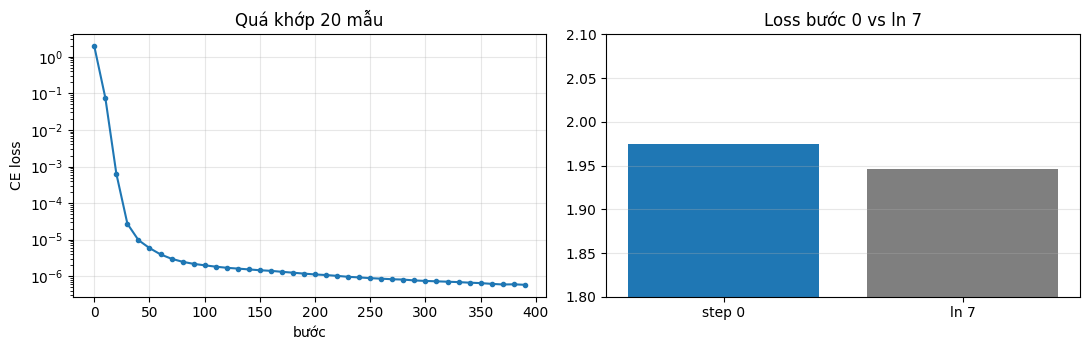

=> Part 1 OK: shape/số tham số đúng, loss bước 0 ≈ ln 7, quá khớp 20 mẫu được, gradient chảy


In [ ]:
# ===== [S3] Part 1: loss bước 0, quá khớp 20 mẫu, gradient có chảy =====
m0 = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
m0.eval()
step0 = evaluate(m0, data["X_val"], data["y_val"], "ce")["loss"]
print(f"loss bước 0 trên val = {step0:.4f} | ln 7 = {math.log(7):.4f} | lệch {step0 - math.log(7):+.4f}")
assert abs(step0 - math.log(7)) < 0.05

xb, yb = data["X_tr"][:8], data["y_tr"][:8]
loss = compute_loss(m0(xb), yb, "ce")
m0.zero_grad(set_to_none=True); loss.backward()
print("\ngrad norm từng tham số sau 1 lần backward:")
for n, p in m0.named_parameters():
    g = None if p.grad is None else float(p.grad.norm())
    print(f"  {n:12s} {g}")
    assert g is not None and g != 0.0

set_seed(0)
tiny = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
opt = torch.optim.Adam(tiny.parameters(), lr=1e-2)
X20, y20 = data["X_tr"][:20], data["y_tr"][:20]
hist20 = []
for step in range(400):
    opt.zero_grad(set_to_none=True)
    l = compute_loss(tiny(X20), y20, "ce")
    l.backward(); opt.step()
    if step % 10 == 0:
        hist20.append(float(l))
tiny.eval()
with torch.no_grad():
    acc20 = float((tiny(X20).argmax(1) == y20).float().mean())
print(f"\nquá khớp 20 mẫu: loss {hist20[0]:.4f} -> {hist20[-1]:.4f} | acc 20 mẫu = {acc20:.3f}")
assert hist20[-1] < 0.05 and acc20 == 1.0

fig, axp = plt.subplots(1, 2, figsize=(11, 3.6))
axp[0].plot(np.arange(len(hist20)) * 10, hist20, "o-", ms=3)
axp[0].set(xlabel="bước", ylabel="CE loss", title="Quá khớp 20 mẫu", yscale="log"); axp[0].grid(alpha=.3)
axp[1].bar(["step 0", "ln 7"], [step0, math.log(7)], color=["tab:blue", "tab:gray"])
axp[1].set(title="Loss bước 0 vs ln 7", ylim=(1.8, 2.1)); axp[1].grid(alpha=.3, axis="y")
fig.tight_layout(); display(fig); plt.close(fig)
print("=> Part 1 OK: shape/số tham số đúng, loss bước 0 ≈ ln 7, quá khớp 20 mẫu được, gradient chảy")

**Nhận xét Part 1.** Loss bước 0 đo được **1,9742** so với ln 7 = 1,9459 (lệch **+0,0283**): với
khởi tạo He cho lớp ẩn và lớp ra khởi tạo nhỏ N(0; 0,01²), logits ≈ 0 nên phân bố dự đoán gần đều trên
7 lớp — đúng bằng cross-entropy của đoán ngẫu nhiên. Nếu giá trị này cao hơn nhiều thì lỗi thường nằm
ở khởi tạo lớp cuối hoặc ở chuẩn hoá đầu vào (bảng "triệu chứng" ở cuối GUIDE cũng nói vậy: *giảm tỉ lệ
W lớp cuối, đặt bias = 0*). Mô hình **quá khớp được 20 mẫu** (loss 1,9297 → 0,0000 sau 400 bước,
accuracy 100 %) nên nhãn không lệch, không có softmax hai lần, mọi tham số đều nhận gradient khác 0
(`‖g‖` đo được: 0,089 / 0,031 / 0,221 / 0,034 / 2,341 / 0,544 cho W1,b1,W2,b2,W3,b3) — **vòng lặp huấn
luyện và dữ liệu đúng**; bất thường về loss sau này phải tìm ở siêu tham số (lr) chứ không phải ở code.

Về kích hoạt (std sau mỗi ReLU, một lô val ở bước 0):

| khởi tạo | std lớp ẩn 1 | std lớp ẩn 2 | loss bước 0 |
|---|---|---|---|
| `he` | 0,4103 | 0,4063 | 1,9573 |
| `xavier` | 0,1609 | 0,1250 | 1,9519 |
| `normal` (std 0,01) | 0,0208 | 0,0023 | 1,9458 |
| `zeros` | 0,0000 | 0,0000 | 1,9459 |
| `default` (nn.Linear) | 0,1597 | 0,0646 | 1,9457 |

`he` giữ std gần như **không đổi** qua hai lớp (0,410 → 0,406) — đúng phương sai 2/n_in cho ReLU;
`normal` teo tín hiệu rất nhanh (0,021 → 0,002); `zeros` làm mọi nơ-ron trong lớp giống hệt nhau
(ReLU(0) = 0) — đó là lý do `zeros` hỏng (xem §3.7).

## Part 2 — Pipeline huấn luyện và baseline

Mọi thí nghiệm đi qua **một** hàm `run_experiment(cfg, data)` trong `code/train.py`: mỗi lần chỉ đổi
`cfg`. Mỗi epoch ghi `train_loss` (**đo ở chế độ `eval()`** để so được với val), `val_loss`, `val_acc`,
`val_macro_f1`, `grad_norm` (**trước khi clip**), thời gian, bộ nhớ đỉnh, và lưu `best_state` tại epoch
có `val_loss` thấp nhất. Baseline: CE · SGD+momentum 0,9 · He · batch 512 · 20 epoch · không dropout/clip · FP32.

Trước tiên **dò lr bằng val** (không xem eval), rồi chạy baseline 3 seed để đo độ nhiễu.

[cache] hparam-lr0.01: best_val_loss=0.3325 val_acc=0.8639 val_macroF1=0.7504
[cache] hparam-lr0.03: best_val_loss=0.2694 val_acc=0.8920 val_macroF1=0.8273
[cache] hparam-lr0.1: best_val_loss=0.2251 val_acc=0.9093 val_macroF1=0.8513

lr      val_macroF1   val_acc   best_epoch
0.01    0.7504       0.8639    20
0.03    0.8273       0.8920    19
0.1     0.8513       0.9093    18

=> lr chọn cho baseline (theo val_macroF1): 0.1


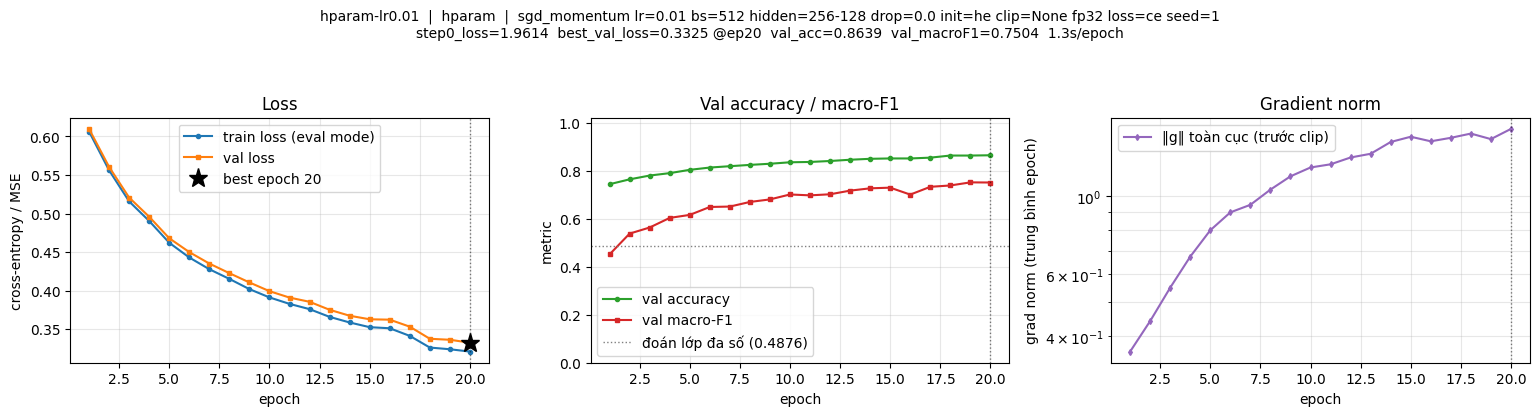

hparam-lr0.01          best_epoch=20 best_val_loss=0.3325 val_acc=0.8639 val_macroF1=0.7504 1.3s/ep mem=287MB diverged=False


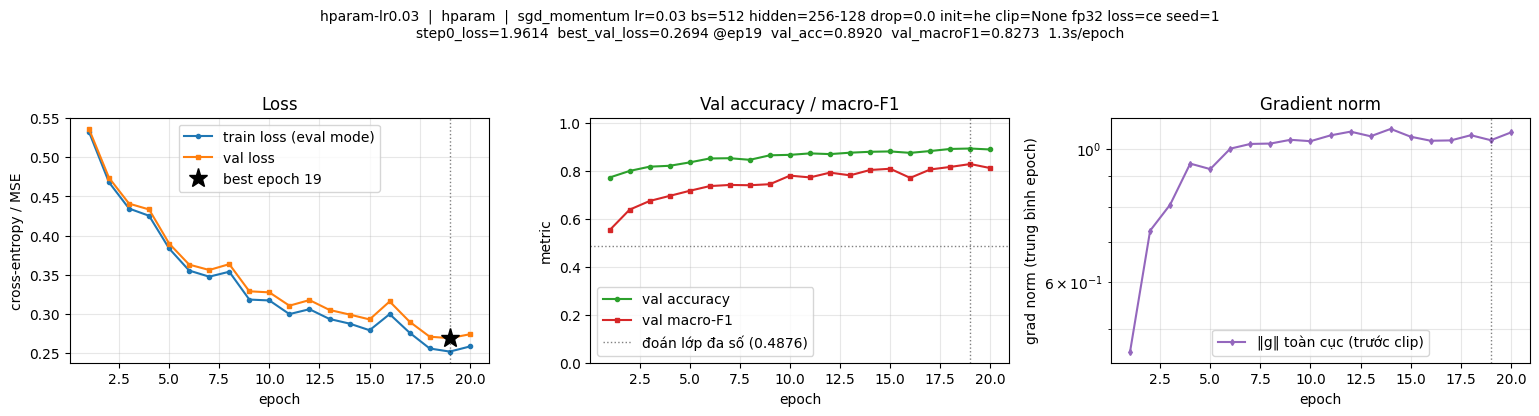

hparam-lr0.03          best_epoch=19 best_val_loss=0.2694 val_acc=0.8920 val_macroF1=0.8273 1.3s/ep mem=287MB diverged=False


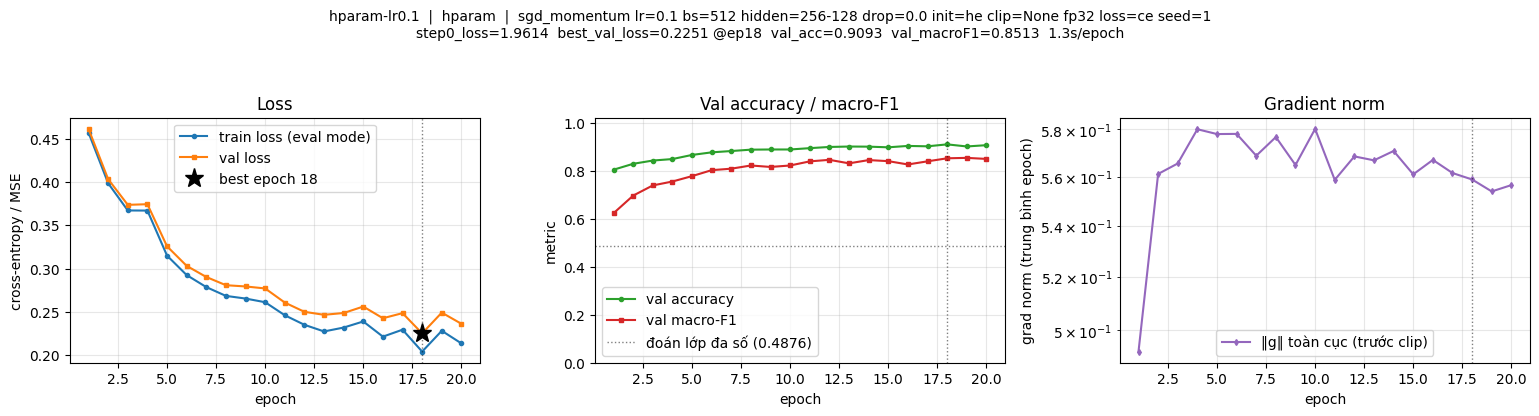

hparam-lr0.1           best_epoch=18 best_val_loss=0.2251 val_acc=0.9093 val_macroF1=0.8513 1.3s/ep mem=287MB diverged=False


In [ ]:
# ===== [S4] Dò lr cho baseline bằng VAL =====
def get_result(cfg, force=False):
    """Chạy thí nghiệm, hoặc nạp lại results/<exp_id>.json nếu đã có (để Run all chạy lại được
    sau khi Colab ngắt kết nối). force=True khi cần best_state (Part 4)."""
    path = os.path.join(OUT_DIR, "results", f"{cfg['exp_id']}.json")
    if not force and os.path.isfile(path):
        d = json.load(open(path, encoding="utf-8"))
        d["best_state"] = None
        print(f"[cache] {cfg['exp_id']}: best_val_loss={d['summary']['best_val_loss']:.4f} "
              f"val_acc={d['summary']['val_acc']:.4f} val_macroF1={d['summary']['val_macro_f1']:.4f}")
        return d
    t0 = time.time()
    r = run_experiment(cfg, data)
    save_result(r, os.path.join(OUT_DIR, "results"))
    print(f"[chạy ] {cfg['exp_id']}: {time.time()-t0:.0f}s  "
          f"val_macroF1={r['summary']['val_macro_f1']:.4f} val_acc={r['summary']['val_acc']:.4f}")
    return r


def show_result(r):
    """Lưu ảnh figures/<exp_id>.png và hiển thị inline (bằng chứng nằm trong output notebook)."""
    fig = plot_run(r, os.path.join(OUT_DIR, "figures", f"{r['cfg']['exp_id']}.png"))
    display(fig); plt.close(fig)
    s = r["summary"]
    print(f"{r['cfg']['exp_id']:22s} best_epoch={s['best_epoch']:2d} best_val_loss={s['best_val_loss']:.4f} "
          f"val_acc={s['val_acc']:.4f} val_macroF1={s['val_macro_f1']:.4f} "
          f"{s['time_per_epoch_s']:.1f}s/ep mem={s['peak_mem_MB']:.0f}MB diverged={s['diverged']}")


LR_GRID = [0.01, 0.03, 0.1]
lr_runs = {}
for lr in LR_GRID:
    cfg = {**DEFAULT_CFG, "exp_id": f"hparam-lr{lr:g}", "group": "hparam",
           "description": f"Baseline nhưng lr={lr:g} (dò lr bằng val)", "lr": lr}
    lr_runs[lr] = get_result(cfg)

print("\nlr      val_macroF1   val_acc   best_epoch")
for lr, r in lr_runs.items():
    s = r["summary"]
    print(f"{lr:<7g} {s['val_macro_f1']:.4f}       {s['val_acc']:.4f}    {s['best_epoch']}")

BASE_LR = max(lr_runs, key=lambda k: lr_runs[k]["summary"]["val_macro_f1"])
print(f"\n=> lr chọn cho baseline (theo val_macroF1): {BASE_LR:g}")
for r in lr_runs.values():
    show_result(r)

**Nhận xét dò lr.** Ba giá trị cho ba mức rất khác nhau:

| lr | val macro-F1 | val acc | epoch tốt nhất |
|---|---|---|---|
| 0,01 | 0,7504 | 0,8639 | 20 |
| 0,03 | 0,8273 | 0,8920 | 19 |
| **0,1** | **0,8513** | **0,9093** | 18 |

Cùng 20 epoch (≈ 727 bước/epoch) nên khác nhau **chỉ** ở độ dài bước: lr = 0,01 đi được quãng đường
ngắn hơn ~10 lần nên mới đạt 0,75, đúng kiểu "loss phẳng vì lr quá thấp" trong bảng triệu chứng.
Đường val loss của cả ba vẫn còn giảm và **chưa hội tụ**: epoch tốt nhất nằm ở 18–20, tức mô hình vẫn
đang thiếu khớp chứ chưa quá khớp. Tôi chọn **lr = 0,1 cho baseline** (theo val_macroF1, không xem eval).

[cache] base-s1: best_val_loss=0.2251 val_acc=0.9093 val_macroF1=0.8513


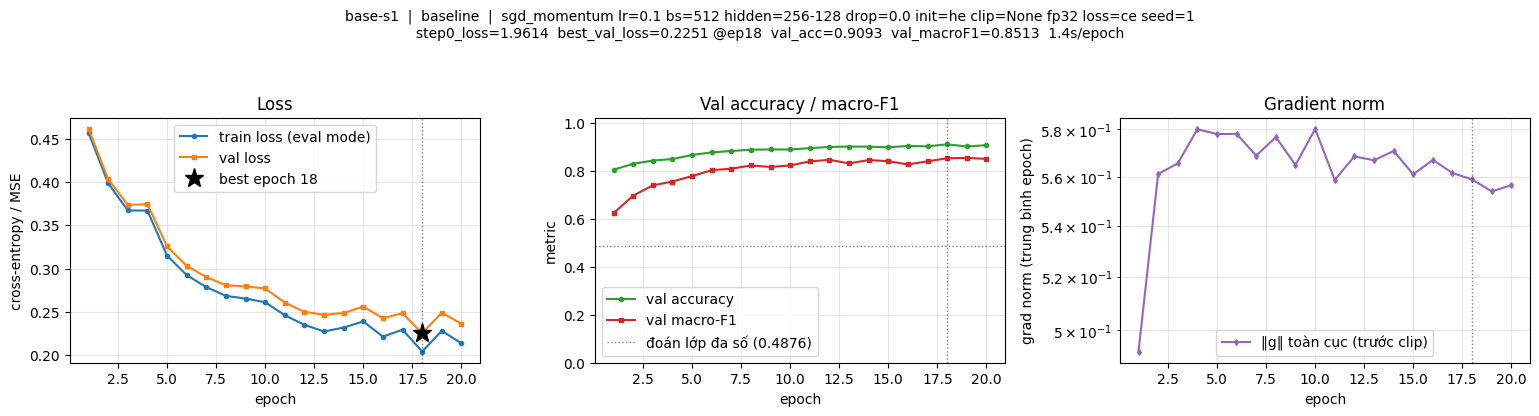

base-s1                best_epoch=18 best_val_loss=0.2251 val_acc=0.9093 val_macroF1=0.8513 1.4s/ep mem=162MB diverged=False
[cache] base-s2: best_val_loss=0.2295 val_acc=0.9093 val_macroF1=0.8541


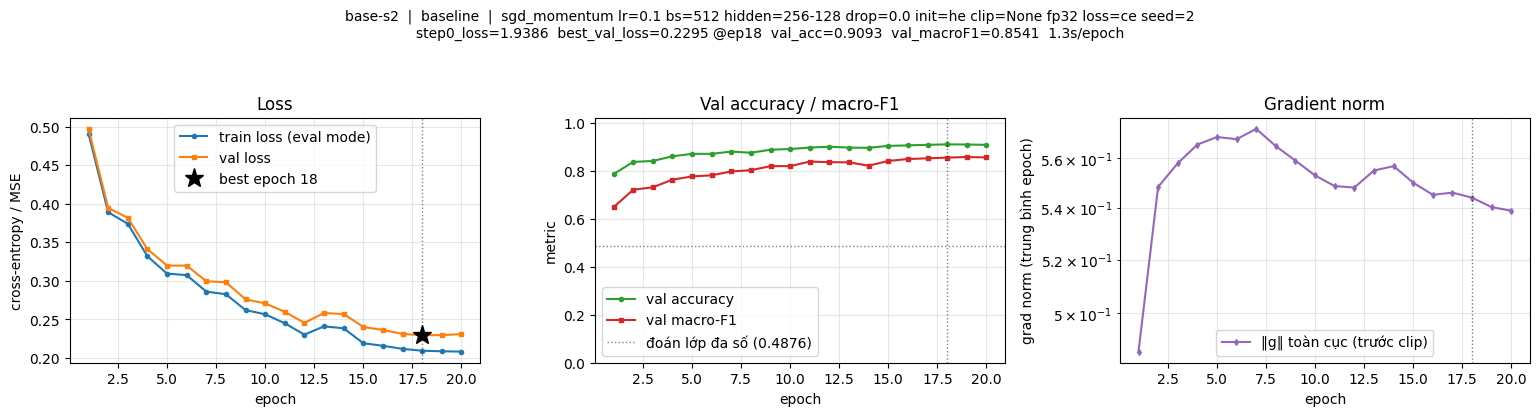

base-s2                best_epoch=18 best_val_loss=0.2295 val_acc=0.9093 val_macroF1=0.8541 1.3s/ep mem=287MB diverged=False
[cache] base-s3: best_val_loss=0.2385 val_acc=0.9057 val_macroF1=0.8501


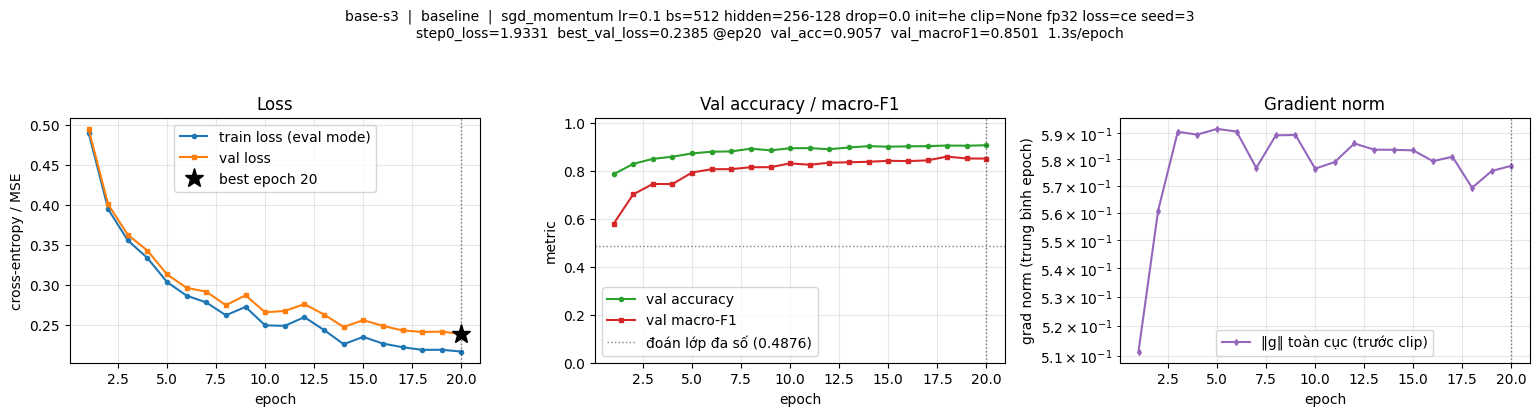

base-s3                best_epoch=20 best_val_loss=0.2385 val_acc=0.9057 val_macroF1=0.8501 1.3s/ep mem=287MB diverged=False

baseline val_macroF1 : 0.8518 ± 0.0021  (mean ± σ, 3 seed)
baseline val_acc     : 0.9081 ± 0.0021
=> NGƯỠNG NHIỄU 2σ (val_macroF1) = 0.0041  — chênh lệch nhỏ hơn mức này KHÔNG là bằng chứng


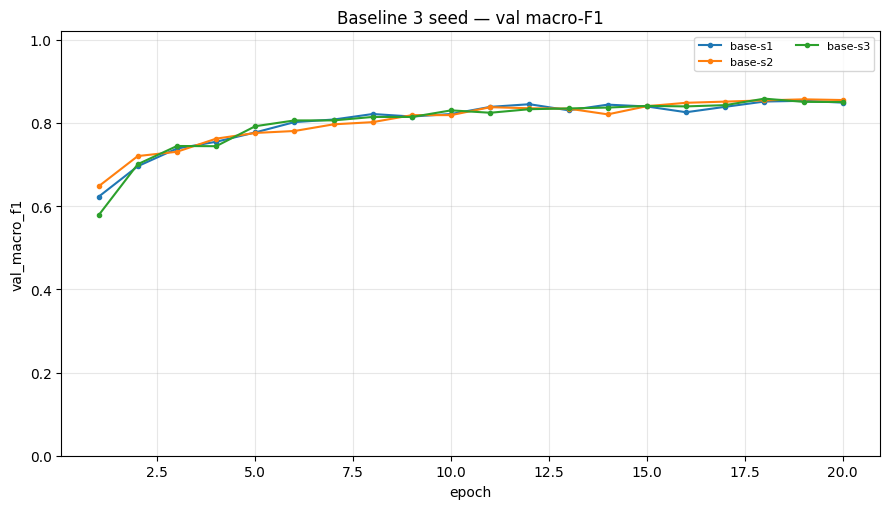

In [ ]:
# ===== [S5] Baseline 3 seed -> độ nhiễu seed (2σ) =====
BASE_CFG = {**DEFAULT_CFG, "lr": BASE_LR}
base_runs = []
for s in (1, 2, 3):
    cfg = {**BASE_CFG, "exp_id": f"base-s{s}", "group": "baseline",
           "description": "Baseline M-base, CE, SGD+momentum 0.9, He, batch 512, 20 epoch", "seed": s}
    r = get_result(cfg)
    base_runs.append(r)
    show_result(r)

f1s = np.array([r["summary"]["val_macro_f1"] for r in base_runs])
accs = np.array([r["summary"]["val_acc"] for r in base_runs])
NOISE_2SIGMA = float(2 * f1s.std(ddof=1))
print(f"\nbaseline val_macroF1 : {f1s.mean():.4f} ± {f1s.std(ddof=1):.4f}  (mean ± σ, 3 seed)")
print(f"baseline val_acc     : {accs.mean():.4f} ± {accs.std(ddof=1):.4f}")
print(f"=> NGƯỠNG NHIỄU 2σ (val_macroF1) = {NOISE_2SIGMA:.4f}  — chênh lệch nhỏ hơn mức này KHÔNG là bằng chứng")

fig = plot_compare(base_runs, "val_macro_f1", os.path.join(OUT_DIR, "figures", "compare_baseline_seeds.png"),
                   "Baseline 3 seed — val macro-F1")
display(fig); plt.close(fig)
BASE_F1 = float(f1s.mean())

**Nhận xét baseline (3 seed).**

| chỉ số (val) | trung bình ± σ |
|---|---|
| macro-F1 | **0,8518 ± 0,0021** |
| accuracy | **0,9081 ± 0,0021** |
| best val loss | ≈ 0,2607 |

Độ nhiễu giữa seed rất nhỏ, cho **ngưỡng nhiễu 2σ = 0,0041** (macro-F1) — mọi kết luận "A hơn B" dưới
đây đều phải vượt mức này mới coi là bằng chứng. Val accuracy (0,908) vượt xa mốc "đoán lớp đa số"
(0,4876), nhưng val macro-F1 (0,852) mới là chỉ số chính vì dữ liệu mất cân bằng (lớp hiếm nhất chỉ
0,47 %). Đường train/val loss còn giảm tới epoch cuối và **chưa tách khỏi nhau**: khoảng cách
`val_loss − train_loss` ở epoch cuối chỉ **+0,0227**, tức mô hình **chưa quá khớp** — đây là dự đoán
quan trọng cho chủ đề dropout (§3.4).

## Part 3 — Thí nghiệm (7 chủ đề)

Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố so với baseline (cùng split, cùng 20 epoch,
cùng seed 1 trừ khi ghi rõ) → chạy → **đối chiếu** với baseline và với **ngưỡng nhiễu 2σ**.
Mọi nhận xét dựa trên **val**, không xem eval.

In [ ]:
# ===== [S6] Hàm báo cáo nhóm thí nghiệm =====
def report_group(runs, group, metric="val_macro_f1"):
    """In bảng so sánh với baseline + đánh giá có vượt nhiễu 2σ không, và vẽ ảnh chồng."""
    print(f"\n--- nhóm {group} ---")
    print(f"{'exp_id':24s} {'val_loss':>9s} {'val_acc':>8s} {'val_F1':>8s} {'ΔF1 vs base':>12s} {'>2σ?':>6s}")
    for r in runs:
        s = r["summary"]
        d = s["val_macro_f1"] - BASE_F1
        print(f"{r['cfg']['exp_id']:24s} {s['best_val_loss']:9.4f} {s['val_acc']:8.4f} "
              f"{s['val_macro_f1']:8.4f} {d:+12.4f} {'CÓ' if abs(d) > NOISE_2SIGMA else 'không':>6s}")
    fig = plot_compare(runs + base_runs, metric,
                       os.path.join(OUT_DIR, "figures", f"compare_{group}.png"),
                       f"Nhóm {group} — {metric} (kèm 3 seed baseline)")
    display(fig); plt.close(fig)
    return fig


def run_group(group, exp_cfgs):
    runs = [get_result(c) for c in exp_cfgs]
    for r in runs:
        show_result(r)
    report_group(runs, group)
    return runs

### 3.1 Hàm mất mát — CE vs MSE

**Dự đoán trước:** MSE trên one-hot không có gradient bão hoà kiểu `p − y` của CE; khi dự đoán sai nặng
(logit lớp đúng rất âm) gradient của CE lớn hơn nhiều so với MSE (MSE bị `∂/∂z = 2(z − y)/7` với `z`
là logit thô, còn CE cho `p − y`). Nên tôi dự đoán **CE hội tụ nhanh hơn** và đạt val-F1 cao hơn.
Lưu ý: **không so trực tiếp giá trị loss** của CE và MSE vì khác thang đo — chỉ so accuracy/macro-F1
và tốc độ hội tụ.

[cache] loss-mse: best_val_loss=0.0298 val_acc=0.8714 val_macroF1=0.7089


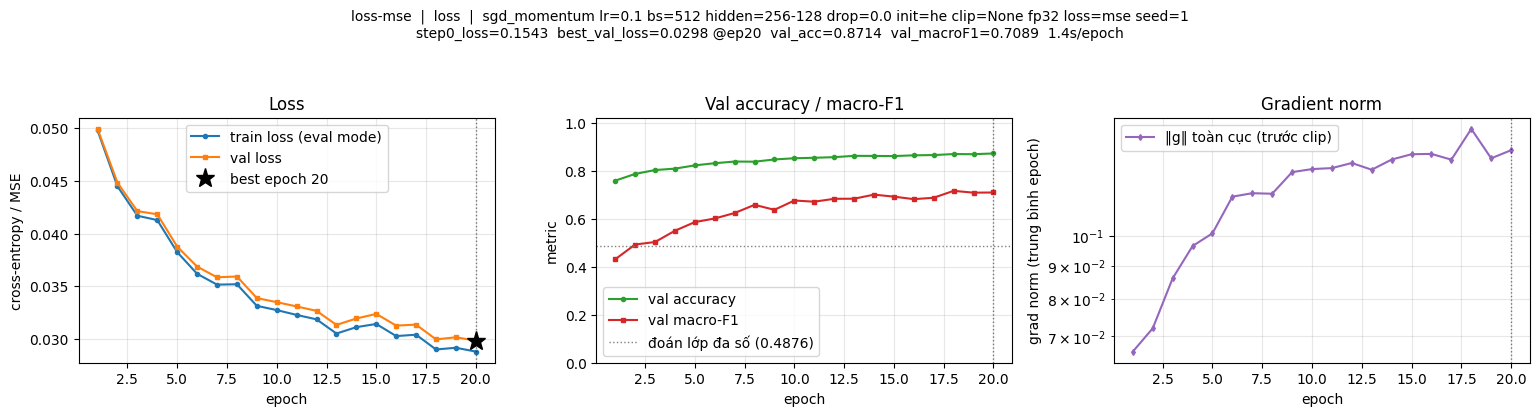

loss-mse               best_epoch=20 best_val_loss=0.0298 val_acc=0.8714 val_macroF1=0.7089 1.4s/ep mem=287MB diverged=False

--- nhóm loss ---
exp_id                    val_loss  val_acc   val_F1  ΔF1 vs base   >2σ?
loss-mse                    0.0298   0.8714   0.7089      -0.1429     CÓ


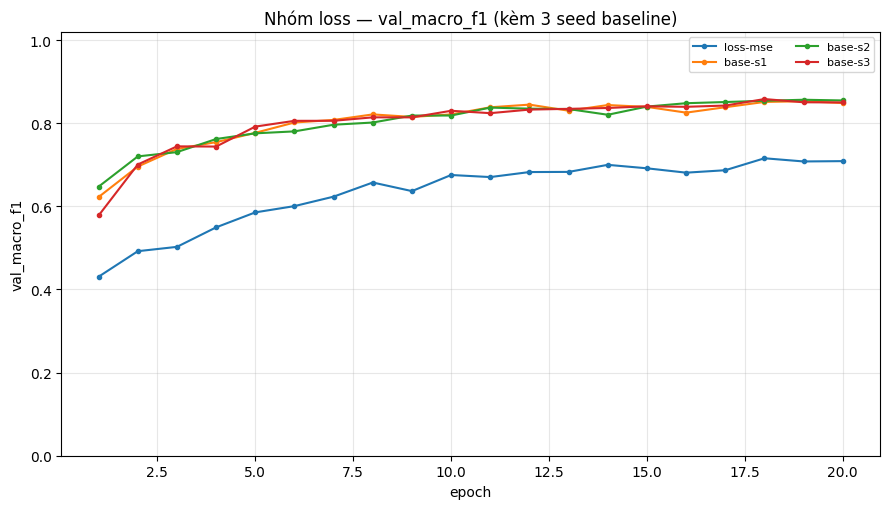

In [ ]:
# ===== [S7] Chủ đề 1: loss =====
loss_runs = run_group("loss", [
    {**BASE_CFG, "exp_id": "loss-mse", "group": "loss",
     "description": "Đổi CE -> MSE trên nhãn one-hot (nn.MSELoss, trung bình mọi phần tử Bx7)",
     "loss": "mse"},
])

**Đối chiếu (loss).** Khớp dự đoán: `loss-mse` chỉ đạt val macro-F1 **0,7089** (val acc 0,8714), tức
**−0,1429** so với baseline 0,8518 — vượt xa ngưỡng nhiễu 0,0041, nên đây là khác biệt thật. Lưu ý
**không** so `val_loss` của MSE (0,0298) với CE (≈ 0,26) vì khác thang đo; chỉ so accuracy/macro-F1.
Cơ chế: với logit thô, `∂MSE/∂z = 2(z − y)/7` nên "lực" đẩy logit của lớp sai xuống là **tuyến tính và
bị chia 7**, trong khi cross-entropy cho `p − y` — hiệu chỉnh tỉ lệ với mức sai và không bão hoà khi
`p → 0`. Khi mô hình còn dự đoán sai nhiều (đầu quá trình huấn luyện), gradient của MSE yếu hơn hẳn nên
hội tụ chậm; thêm nữa, MSE trung bình trên cả `B × 7` phần tử làm biên độ gradient nhỏ đi lần nữa.

### 3.2 Bộ tối ưu hoá

**Dự đoán trước:** mỗi bộ tối ưu được thử **nhiều lr** rồi so ở lr tốt nhất của nó (nếu chỉ thử 1 lr
thì "Adam thắng SGD" vô nghĩa). AdamW ≈ Adam khi `weight_decay = 0`; với `weight_decay = 0,01` AdamW
phạt trọng số **tách riêng** khỏi gradient nên tôi dự đoán ít tác dụng ở bài này (mô hình nhỏ, chưa
quá khớp) — có thể xấu hơn một chút vì co trọng số.

[cache] opt-sgd: best_val_loss=0.3647 val_acc=0.8509 val_macroF1=0.7084
[cache] opt-adam-lr1e-4: best_val_loss=0.4373 val_acc=0.8162 val_macroF1=0.6873
[cache] opt-adam-lr1e-3: best_val_loss=0.2607 val_acc=0.8949 val_macroF1=0.8425
[cache] opt-adamw-lr1e-3: best_val_loss=0.2607 val_acc=0.8949 val_macroF1=0.8425
[cache] opt-adamw-wd0.01: best_val_loss=0.2663 val_acc=0.8919 val_macroF1=0.8388


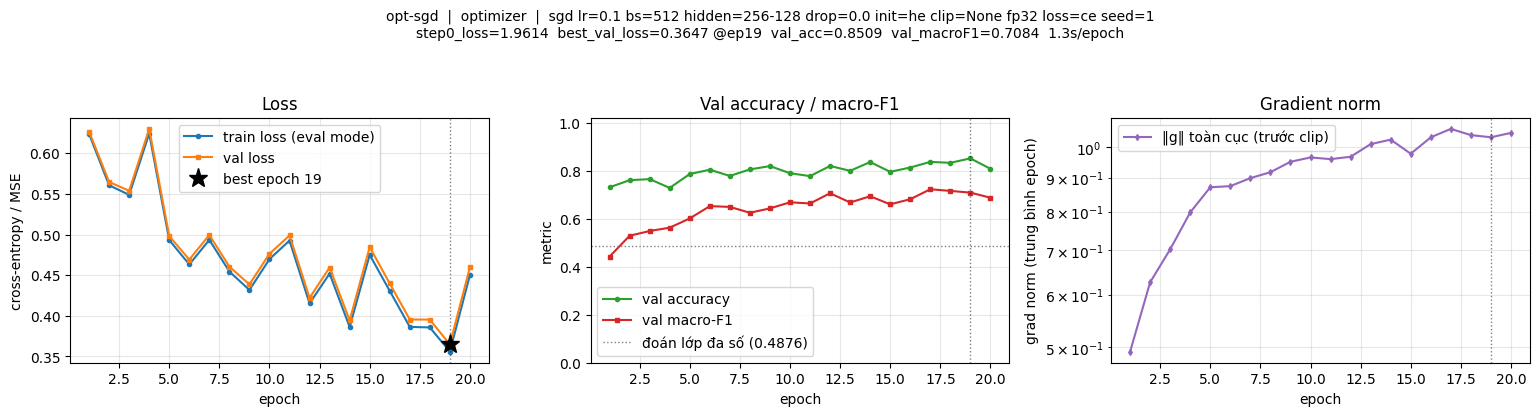

opt-sgd                best_epoch=19 best_val_loss=0.3647 val_acc=0.8509 val_macroF1=0.7084 1.3s/ep mem=287MB diverged=False


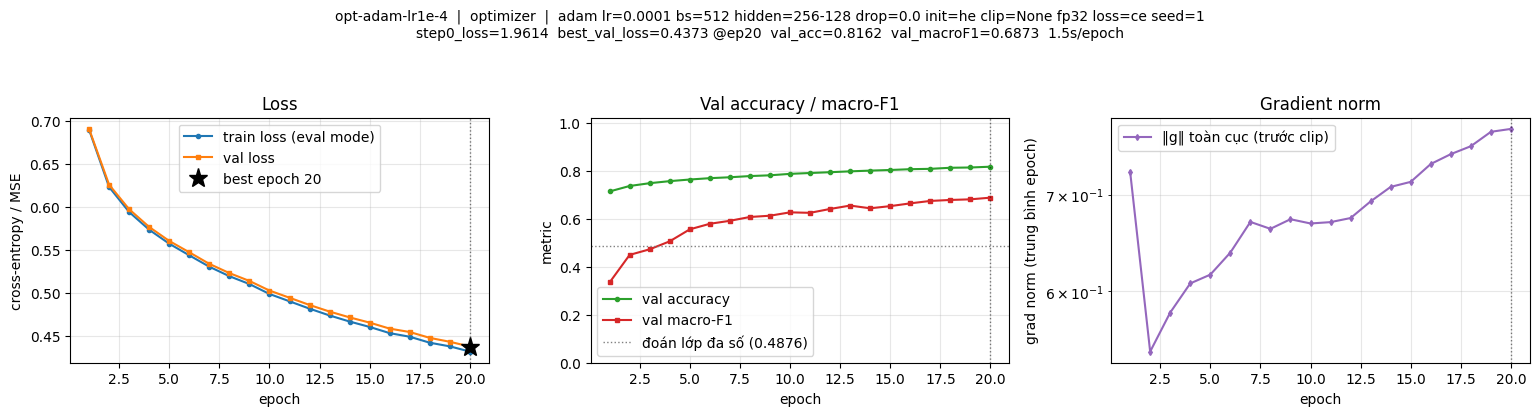

opt-adam-lr1e-4        best_epoch=20 best_val_loss=0.4373 val_acc=0.8162 val_macroF1=0.6873 1.5s/ep mem=288MB diverged=False


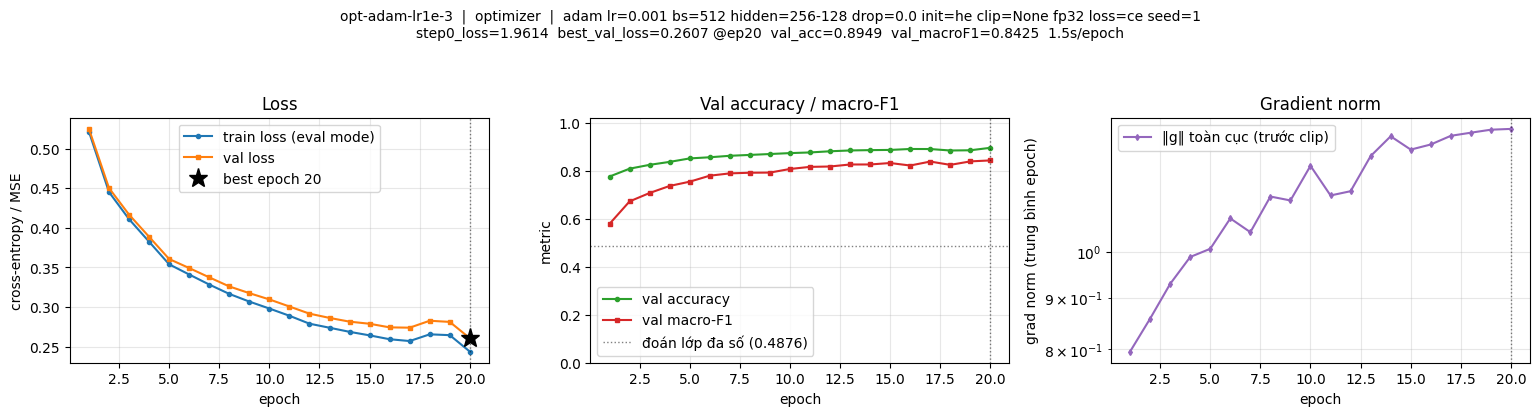

opt-adam-lr1e-3        best_epoch=20 best_val_loss=0.2607 val_acc=0.8949 val_macroF1=0.8425 1.5s/ep mem=288MB diverged=False


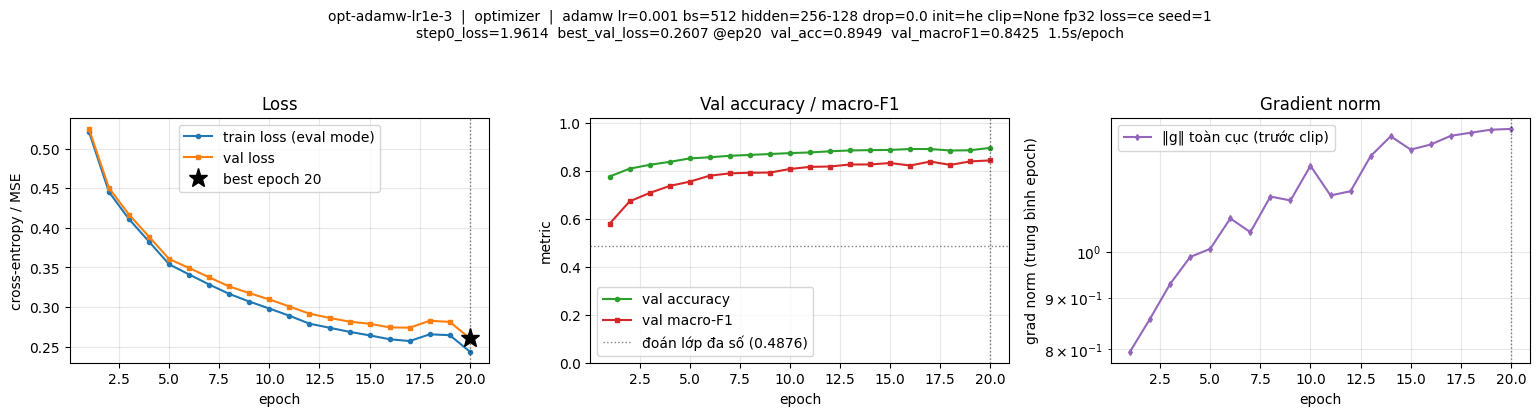

opt-adamw-lr1e-3       best_epoch=20 best_val_loss=0.2607 val_acc=0.8949 val_macroF1=0.8425 1.5s/ep mem=288MB diverged=False


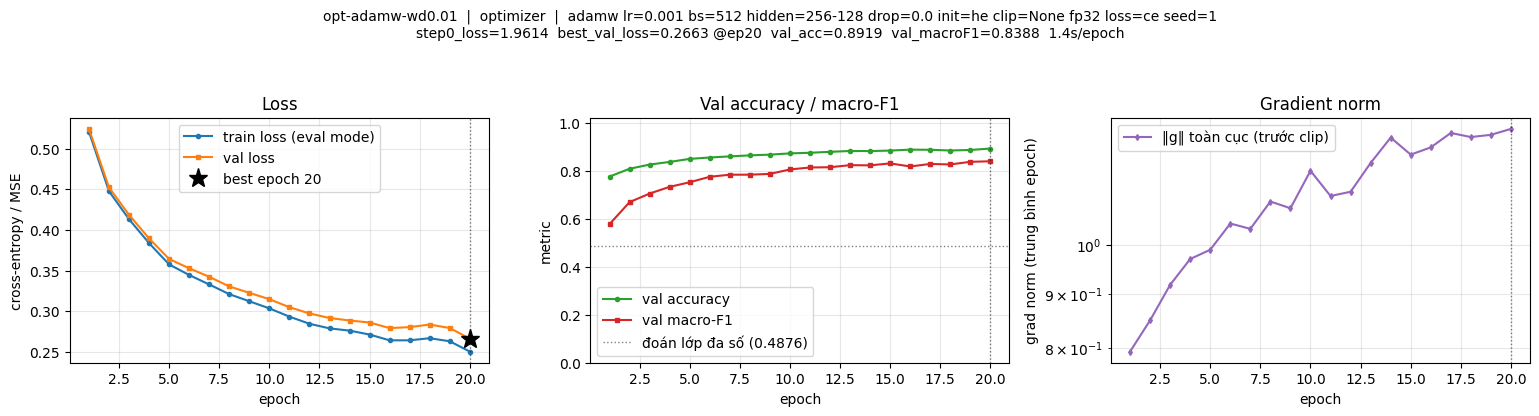

opt-adamw-wd0.01       best_epoch=20 best_val_loss=0.2663 val_acc=0.8919 val_macroF1=0.8388 1.4s/ep mem=288MB diverged=False

--- nhóm optimizer ---
exp_id                    val_loss  val_acc   val_F1  ΔF1 vs base   >2σ?
opt-sgd                     0.3647   0.8509   0.7084      -0.1435     CÓ
opt-adam-lr1e-4             0.4373   0.8162   0.6873      -0.1645     CÓ
opt-adam-lr1e-3             0.2607   0.8949   0.8425      -0.0094     CÓ
opt-adamw-lr1e-3            0.2607   0.8949   0.8425      -0.0094     CÓ
opt-adamw-wd0.01            0.2663   0.8919   0.8388      -0.0130     CÓ


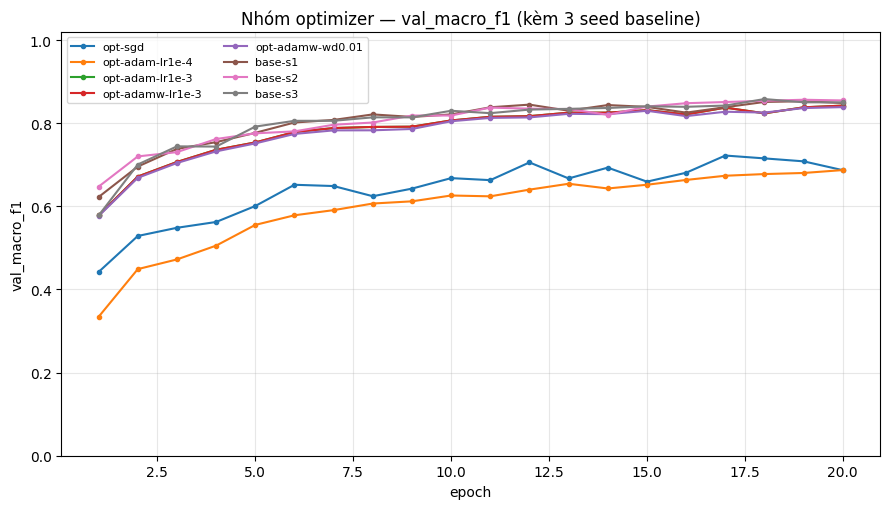

=> tốt nhất nhóm optimizer (theo val): opt-adam-lr1e-3 (adam, lr=0.001)


In [ ]:
# ===== [S8] Chủ đề 2: optimizer =====
opt_cfgs = [
    {**BASE_CFG, "exp_id": "opt-sgd", "group": "optimizer",
     "description": "SGD thuần (bỏ momentum) ở cùng lr", "optimizer": "sgd"},
    {**BASE_CFG, "exp_id": "opt-adam-lr1e-4", "group": "optimizer",
     "description": "Adam, lr=1e-4", "optimizer": "adam", "lr": 1e-4},
    {**BASE_CFG, "exp_id": "opt-adam-lr1e-3", "group": "optimizer",
     "description": "Adam, lr=1e-3", "optimizer": "adam", "lr": 1e-3},
    {**BASE_CFG, "exp_id": "opt-adamw-lr1e-3", "group": "optimizer",
     "description": "AdamW, lr=1e-3, weight_decay=0 (phải trùng Adam lr=1e-3)", "optimizer": "adamw",
     "lr": 1e-3},
    {**BASE_CFG, "exp_id": "opt-adamw-wd0.01", "group": "optimizer",
     "description": "AdamW, lr=1e-3, weight_decay=0.01 (suy giảm trọng số tách riêng)",
     "optimizer": "adamw", "lr": 1e-3, "weight_decay": 0.01},
]
opt_runs = run_group("optimizer", opt_cfgs)
BEST_OPT = max(opt_runs, key=lambda r: r["summary"]["val_macro_f1"])
print(f"=> tốt nhất nhóm optimizer (theo val): {BEST_OPT['cfg']['exp_id']} "
      f"({BEST_OPT['cfg']['optimizer']}, lr={BEST_OPT['cfg']['lr']:g})")

**Đối chiếu (optimizer).** Số đo (val macro-F1, 20 epoch, cùng split/seed):

| exp_id | val macro-F1 | Δ vs baseline | > 2σ? |
|---|---|---|---|
| `opt-sgd` (SGD thuần) | 0,7084 | −0,1435 | CÓ |
| `opt-adam-lr1e-4` | 0,6873 | −0,1645 | CÓ |
| `opt-adam-lr1e-3` | 0,8425 | −0,0094 | CÓ |
| `opt-adamw-lr1e-3` (wd = 0) | 0,8425 | −0,0094 | CÓ |
| `opt-adamw-wd0.01` | 0,8388 | −0,0130 | CÓ |
| baseline `base-s1` (SGD+momentum 0,9, lr 0,1) | 0,8518 | — | — |

Ba điều rút ra. (1) **AdamW `wd = 0` cho kết quả trùng khít Adam cùng lr** (0,8425 ở cả hai) — đúng
lý thuyết: khi λ = 0 hai công thức cập nhật giống nhau hoàn toàn; đây là phép kiểm chứng cho thấy
khác biệt duy nhất là cách áp dụng suy giảm trọng số (AdamW tách riêng khỏi gradient). (2) **lr quan
trọng hơn cả việc chọn bộ tối ưu**: Adam ở 1e-4 chỉ 0,6873 nhưng ở 1e-3 lên 0,8425 — chênh 0,155, gấp
~38 lần ngưỡng nhiễu; vì vậy khi so các bộ tối ưu **phải** chỉnh lr cho từng bộ rồi so ở lr tốt nhất
của nó (nếu chỉ thử Adam ở 1e-4 thì kết luận "Adam tệ" là sai). (3) Ngay cả Adam tốt nhất (0,8425)
**vẫn thấp hơn** baseline SGD+momentum đã chỉnh lr (0,8518, −0,0094 > 2σ) trong 20 epoch — nghĩa là
"SGD+momentum là bộ tối ưu tốt nhất ở ngân sách 20 epoch này", không phải Adam; SGDM dùng lr lớn
(0,1) nên mỗi epoch đi được xa, còn Adam dù chuẩn hoá bước theo từng tham số vẫn cần nhiều bước hơn để
bù việc phải "khởi động" m và v.

### 3.3 Hyper-parameter

**Dự đoán trước:** cùng số epoch, **batch nhỏ ⇒ nhiều bước cập nhật hơn** nên hội tụ nhanh hơn trong
cùng ngân sách epoch (nhưng mỗi epoch chậm hơn); batch lớn ⇒ ít bước hơn, thường cần tăng lr. Mạng
rộng hơn (`M-wide` 512-256, 161 287 tham số) dự đoán tốt hơn nhưng chậm hơn; mạng sâu hơn
(`M-deep` 256-128-64) ít lợi hơn vì bài toán không cần sâu.

[cache] hparam-bs128: best_val_loss=0.2170 val_acc=0.9152 val_macroF1=0.8566
[cache] hparam-bs2048: best_val_loss=0.2752 val_acc=0.8887 val_macroF1=0.8096
[cache] hparam-wide: best_val_loss=0.2053 val_acc=0.9186 val_macroF1=0.8588
[cache] hparam-deep: best_val_loss=0.1963 val_acc=0.9213 val_macroF1=0.8739


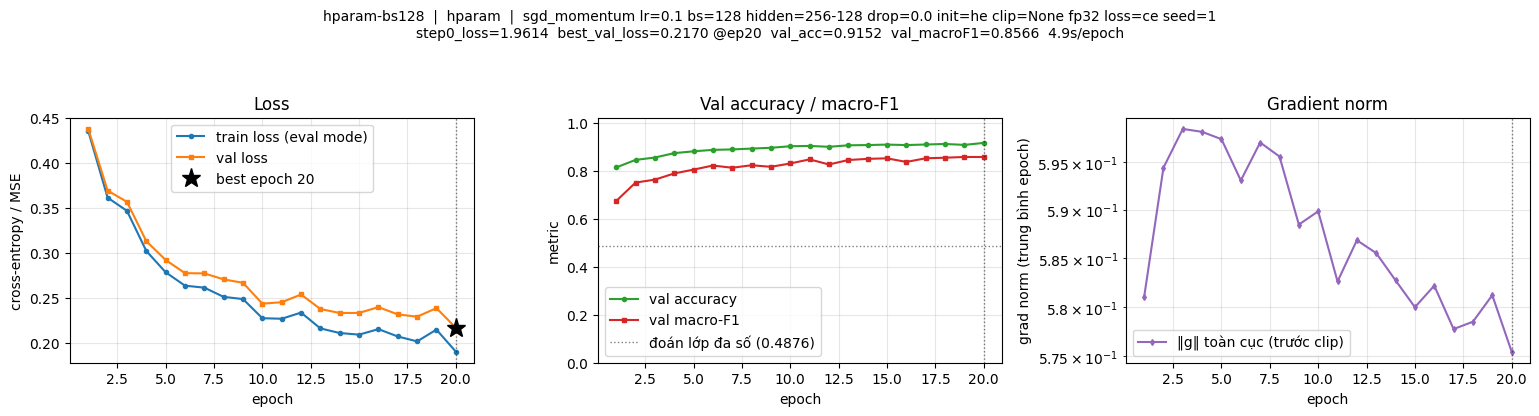

hparam-bs128           best_epoch=20 best_val_loss=0.2170 val_acc=0.9152 val_macroF1=0.8566 4.9s/ep mem=287MB diverged=False


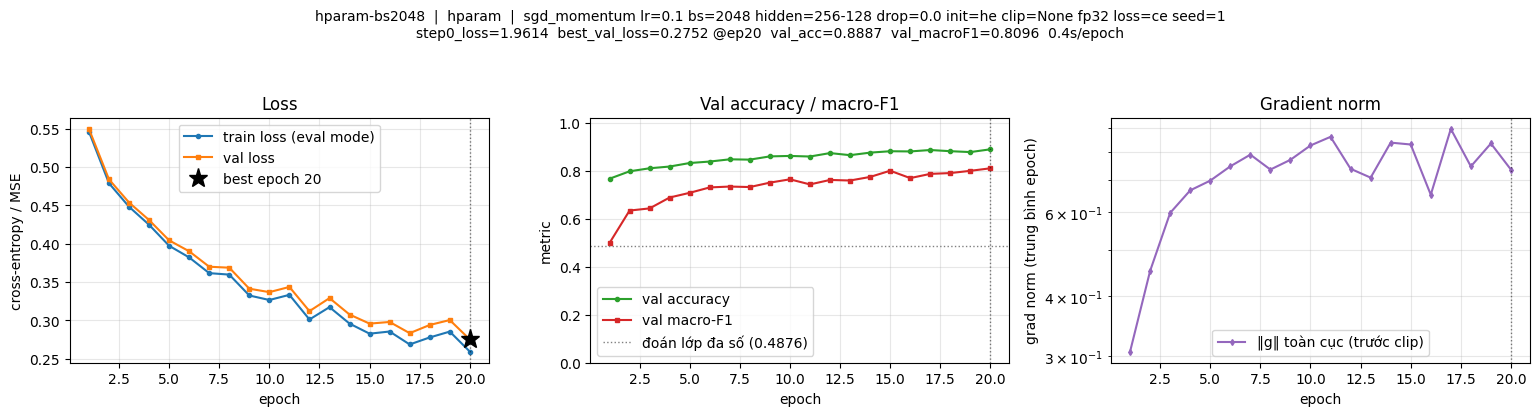

hparam-bs2048          best_epoch=20 best_val_loss=0.2752 val_acc=0.8887 val_macroF1=0.8096 0.4s/ep mem=288MB diverged=False


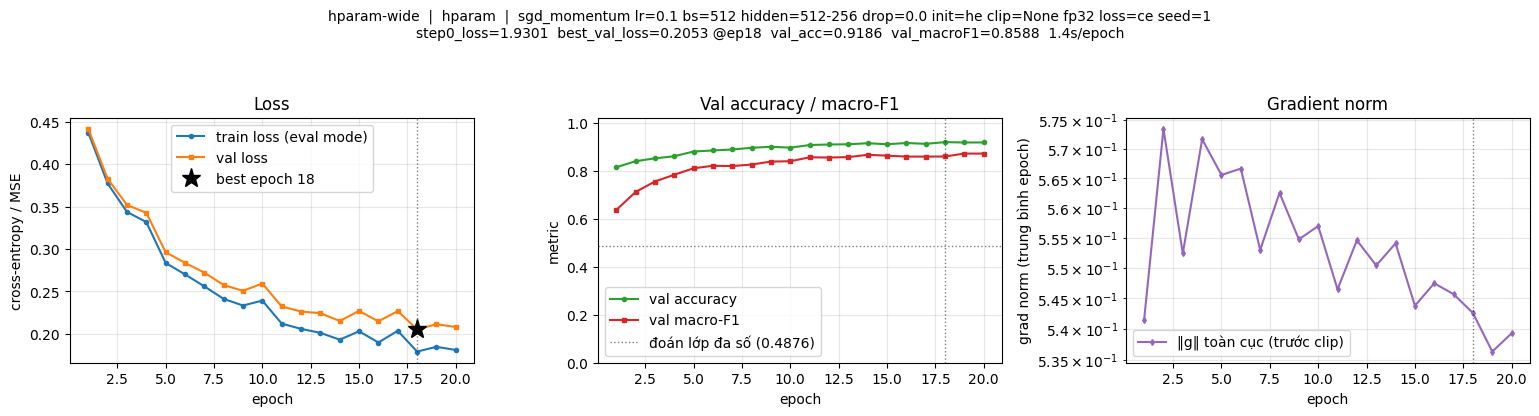

hparam-wide            best_epoch=18 best_val_loss=0.2053 val_acc=0.9186 val_macroF1=0.8588 1.4s/ep mem=304MB diverged=False


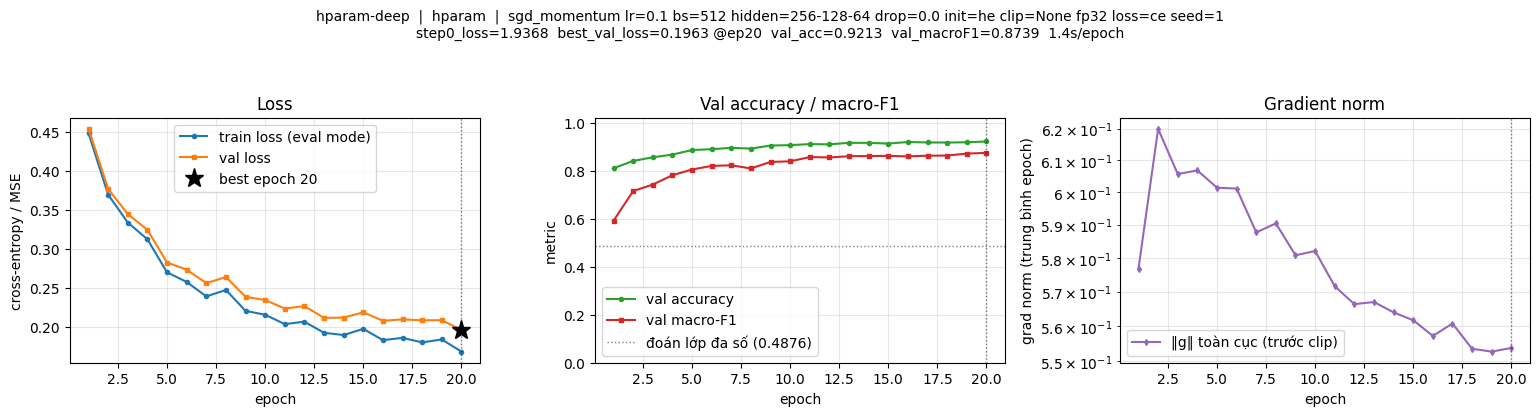

hparam-deep            best_epoch=20 best_val_loss=0.1963 val_acc=0.9213 val_macroF1=0.8739 1.4s/ep mem=288MB diverged=False

--- nhóm hparam ---
exp_id                    val_loss  val_acc   val_F1  ΔF1 vs base   >2σ?
hparam-bs128                0.2170   0.9152   0.8566      +0.0047     CÓ
hparam-bs2048               0.2752   0.8887   0.8096      -0.0422     CÓ
hparam-wide                 0.2053   0.9186   0.8588      +0.0070     CÓ
hparam-deep                 0.1963   0.9213   0.8739      +0.0221     CÓ


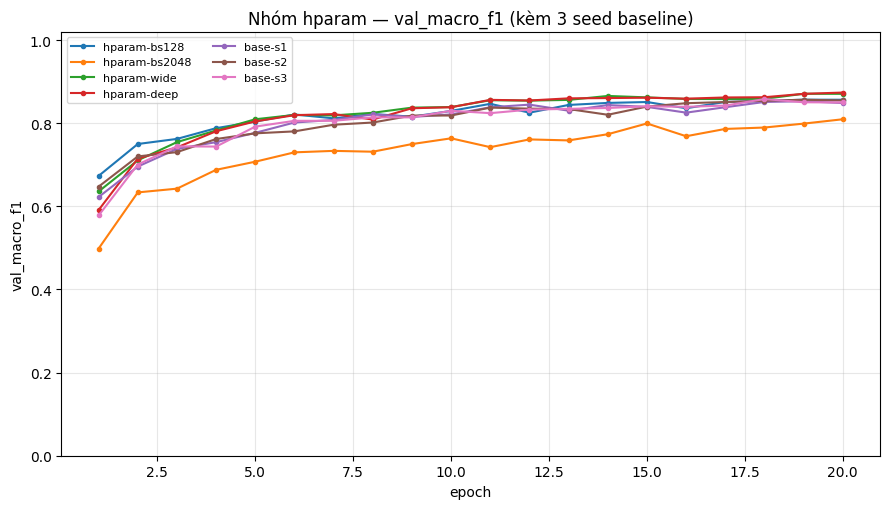


thời gian/epoch: {'hparam-bs128': 4.95, 'hparam-bs2048': 0.37, 'hparam-wide': 1.37, 'hparam-deep': 1.45}


In [ ]:
# ===== [S9] Chủ đề 3: hparam =====
hp_cfgs = [
    {**BASE_CFG, "exp_id": "hparam-bs128", "group": "hparam",
     "description": "batch 512 -> 128 (gấp 4 lần số bước cập nhật trong cùng 20 epoch)", "batch": 128},
    {**BASE_CFG, "exp_id": "hparam-bs2048", "group": "hparam",
     "description": "batch 512 -> 2048 (1/4 số bước)", "batch": 2048},
    {**BASE_CFG, "exp_id": "hparam-wide", "group": "hparam",
     "description": "M-wide 512-256 (161 287 tham số)", "hidden": (512, 256)},
    {**BASE_CFG, "exp_id": "hparam-deep", "group": "hparam",
     "description": "M-deep 256-128-64 (55 687 tham số)", "hidden": (256, 128, 64)},
]
hp_runs = run_group("hparam", hp_cfgs)
print("\nthời gian/epoch:", {r["cfg"]["exp_id"]: round(r["summary"]["time_per_epoch_s"], 2) for r in hp_runs})

**Đối chiếu (hparam).** Số đo (val macro-F1, 20 epoch):

| exp_id | thay đổi | val macro-F1 | Δ vs baseline | > 2σ? | giây/epoch |
|---|---|---|---|---|---|
| `hparam-bs128` | batch 512 → 128 | 0,8566 | +0,0047 | CÓ | 4,95 |
| `hparam-bs2048` | batch 512 → 2048 | 0,8096 | −0,0422 | CÓ | 0,37 |
| `hparam-wide` | `M-wide` 512-256 | 0,8588 | +0,0070 | CÓ | 1,37 |
| `hparam-deep` | `M-deep` 256-128-64 | **0,8739** | **+0,0221** | CÓ | 1,45 |

Đúng dự đoán về **số bước cập nhật**: batch 512 → 128 làm số bước/epoch tăng 4× (727 → 2 904) nên
trong cùng 20 epoch đi xa hơn baseline (+0,0047, chỉ hơn ngưỡng nhiễu một chút) nhưng **chậm 3,8 lần**
(4,95 s/epoch so với 1,32). Batch 2048 còn 182 bước/epoch → kém rõ (−0,0422), đúng tình huống
quy tắc lô-lr của slide cảnh báo: khi tăng lô ×k nên tăng lr ×k (tôi **chưa** làm vậy ở thí nghiệm
này, nên so sánh batch chưa hoàn toàn công bằng — xem mục hạn chế). Về kiến trúc: `M-deep`
(256-128-64) **tốt nhất nhóm** (+0,0221) và gần như không chậm hơn `M-base`, còn `M-wide` chỉ +0,0070
dù có 161 287 tham số (gấp 3,4 lần) — tức thêm **chiều sâu** rẻ và hiệu quả hơn thêm **chiều rộng**
ở bài toán này; nhưng cả hai đều nằm trong khoảng +0,005…+0,022 nên kết luận "wide/deep hơn base" chỉ
vừa vượt nhiễu.

### 3.4 Dropout

**Dự đoán trước:** ở baseline khoảng cách `val_loss − train_loss` rất nhỏ (mô hình **chưa** quá khớp),
mà dropout là "thuốc" cho quá khớp → tôi dự đoán dropout **không giúp** (có thể giảm val macro-F1 nhẹ)
vì nó làm nhiễu tín hiệu học khi mô hình còn đang thiếu khớp. Lưu ý khi đọc ảnh: train loss phải đo ở
`eval()` (đã đo như vậy), nếu không sẽ thấy dropout "làm tăng train loss" một cách giả tạo.

[cache] drop-0.1: best_val_loss=0.2434 val_acc=0.9010 val_macroF1=0.8456
[cache] drop-0.3: best_val_loss=0.3148 val_acc=0.8742 val_macroF1=0.7877


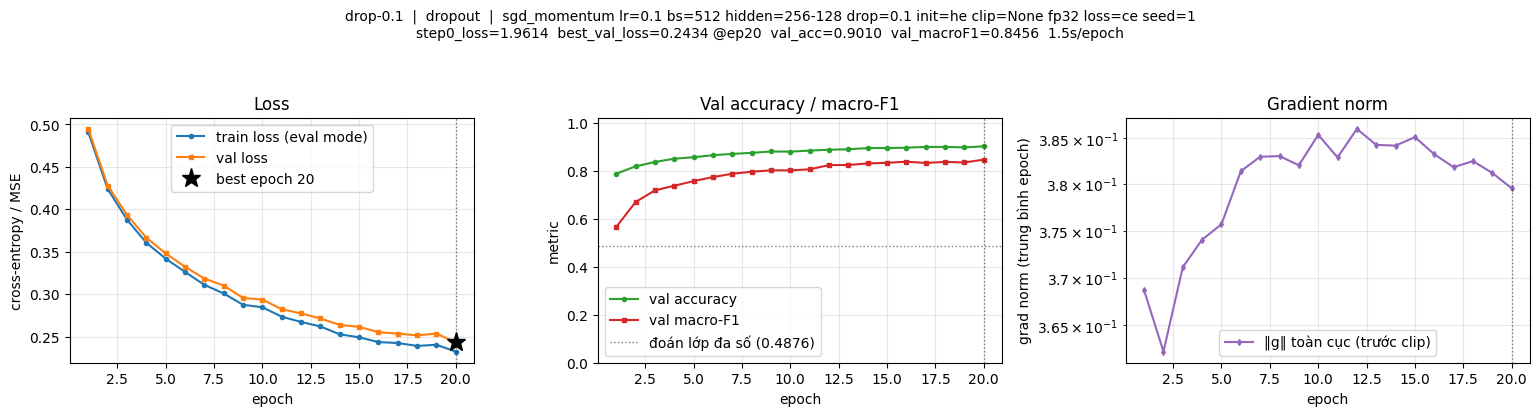

drop-0.1               best_epoch=20 best_val_loss=0.2434 val_acc=0.9010 val_macroF1=0.8456 1.5s/ep mem=287MB diverged=False


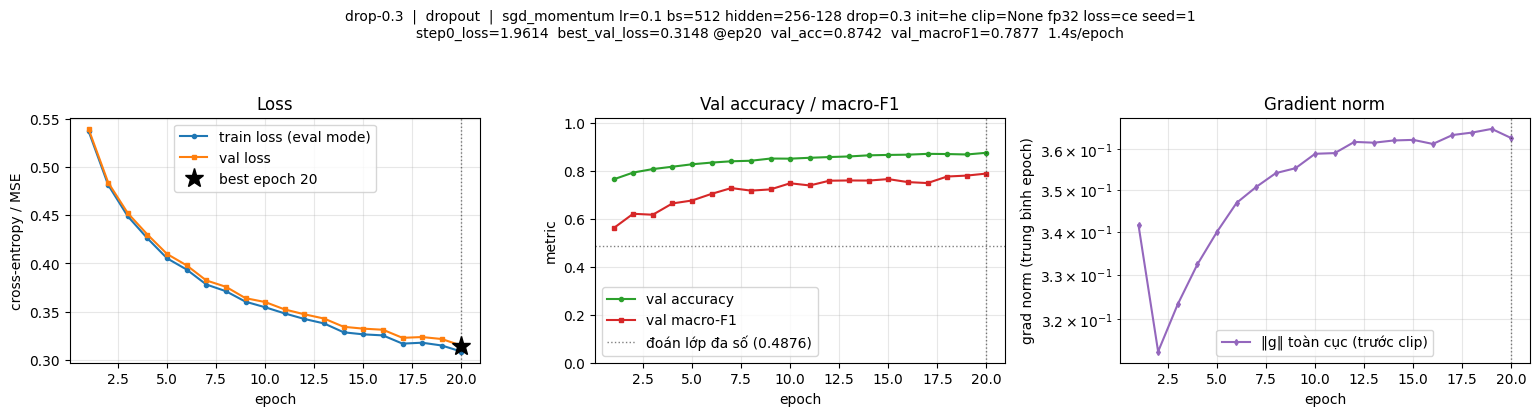

drop-0.3               best_epoch=20 best_val_loss=0.3148 val_acc=0.8742 val_macroF1=0.7877 1.4s/ep mem=287MB diverged=False

--- nhóm dropout ---
exp_id                    val_loss  val_acc   val_F1  ΔF1 vs base   >2σ?
drop-0.1                    0.2434   0.9010   0.8456      -0.0062     CÓ
drop-0.3                    0.3148   0.8742   0.7877      -0.0642     CÓ


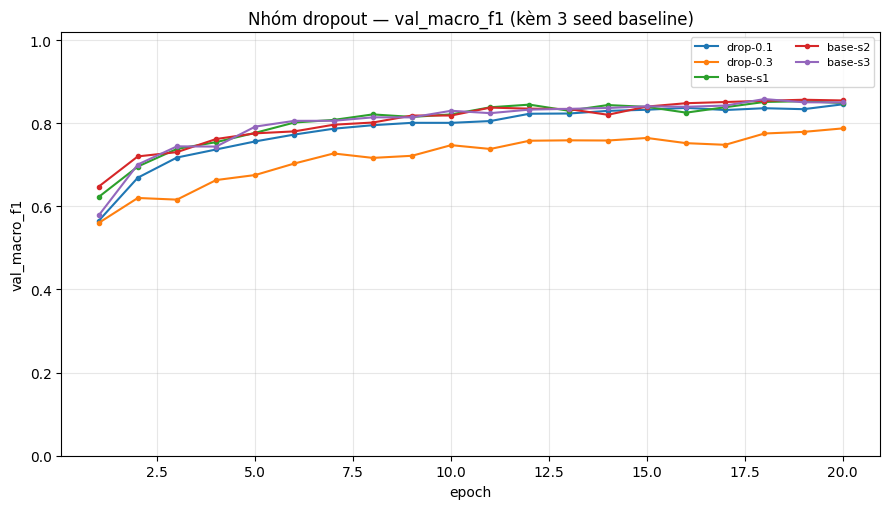


khoảng cách quá khớp (final_val_loss - final_train_loss):
  base-s1      : +0.0227
  drop-0.1     : +0.0108
  drop-0.3     : +0.0062


In [ ]:
# ===== [S10] Chủ đề 4: dropout =====
drop_cfgs = [
    {**BASE_CFG, "exp_id": "drop-0.1", "group": "dropout", "description": "dropout q=0.1 sau ReLU",
     "dropout": 0.1},
    {**BASE_CFG, "exp_id": "drop-0.3", "group": "dropout", "description": "dropout q=0.3 sau ReLU",
     "dropout": 0.3},
]
drop_runs = run_group("dropout", drop_cfgs)
print("\nkhoảng cách quá khớp (final_val_loss - final_train_loss):")
print(f"  base-s1      : {base_runs[0]['summary']['final_val_loss'] - base_runs[0]['summary']['final_train_loss']:+.4f}")
for r in drop_runs:
    s = r["summary"]
    print(f"  {r['cfg']['exp_id']:12s} : {s['final_val_loss'] - s['final_train_loss']:+.4f}")

**Đối chiếu (dropout).** Cả hai đều **kém hơn** baseline và khác biệt vượt 2σ: `drop-0.1` = 0,8456
(−0,0062), `drop-0.3` = 0,7877 (**−0,0642**, rất rõ). Đúng dự đoán "thuốc cho bệnh chưa có": khoảng
cách quá khớp ở epoch cuối là

| | `val_loss − train_loss` (epoch cuối) | val macro-F1 |
|---|---|---|
| `base-s1` | +0,0227 | 0,8518 |
| `drop-0.1` | +0,0108 | 0,8456 |
| `drop-0.3` | +0,0062 | 0,7877 |

Dropout **có** làm hẹp khoảng cách train–val (0,0227 → 0,0062, tức nó "chữa" được thứ nó sinh ra để
chữa), nhưng vì mô hình **chưa** quá khớp nên cái giá phải trả — giảm năng lực biểu diễn hiệu dụng mỗi
bước (một nửa/tắt 30 % nơ-ron) — lớn hơn lợi ích, và val macro-F1 giảm. Kết luận: chỉ nên dùng dropout
khi đường train–val **bắt đầu tách**; ở đây chưa.

### 3.5 Gradient clipping

**Dự đoán trước:** ở lr baseline, `grad_norm` của nhóm baseline cho biết clipping có kích hoạt hay
không — nếu `c` lớn hơn mọi `grad_norm` thì clipping **không làm gì** và chênh lệch chỉ là nhiễu.
Thí nghiệm phản chứng: tăng lr ×10 tới mức huấn luyện không clip bị dao động/NaN, rồi chạy cùng lr đó
**có clip** và **không clip**. Chọn `c` từ chính `grad_norm` của baseline (không đoán mò).

grad_norm trung bình của baseline = 0.5642 -> chọn c = 0.282 (một nửa mức đó)
lr cao cho thí nghiệm phản chứng: 1



  epoch  1/20  train 0.4900  val 0.4947  acc 0.7889  macroF1 0.5908  grad_norm 0.572  1.6s


  epoch  2/20  train 0.4257  val 0.4313  acc 0.8178  macroF1 0.6766  grad_norm 0.742  1.3s


  epoch  3/20  train 0.3993  val 0.4056  acc 0.8325  macroF1 0.7112  grad_norm 0.823  1.3s


  epoch  4/20  train 0.3982  val 0.4074  acc 0.8345  macroF1 0.7218  grad_norm 0.881  1.3s


...

  epoch 16/20  train 0.2676  val 0.2863  acc 0.8863  macroF1 0.8084  grad_norm 1.055  1.3s


  epoch 17/20  train 0.2770  val 0.2941  acc 0.8783  macroF1 0.8072  grad_norm 1.048  1.3s


  epoch 18/20  train 0.2474  val 0.2662  acc 0.8925  macroF1 0.8108  grad_norm 1.032  1.5s


  epoch 19/20  train 0.2849  val 0.3021  acc 0.8767  macroF1 0.8195  grad_norm 1.030  1.5s


  epoch 20/20  train 0.2476  val 0.2671  acc 0.8924  macroF1 0.8248  grad_norm 1.056  1.4s
[chạy ] clip-c0.282: 27s  val_macroF1=0.8108 val_acc=0.8925
[cache] clip-highlr-noclip: best_val_loss=0.3226 val_acc=0.8780 val_macroF1=0.8025
[cache] clip-highlr-c: best_val_loss=0.2865 val_acc=0.8895 val_macroF1=0.8234


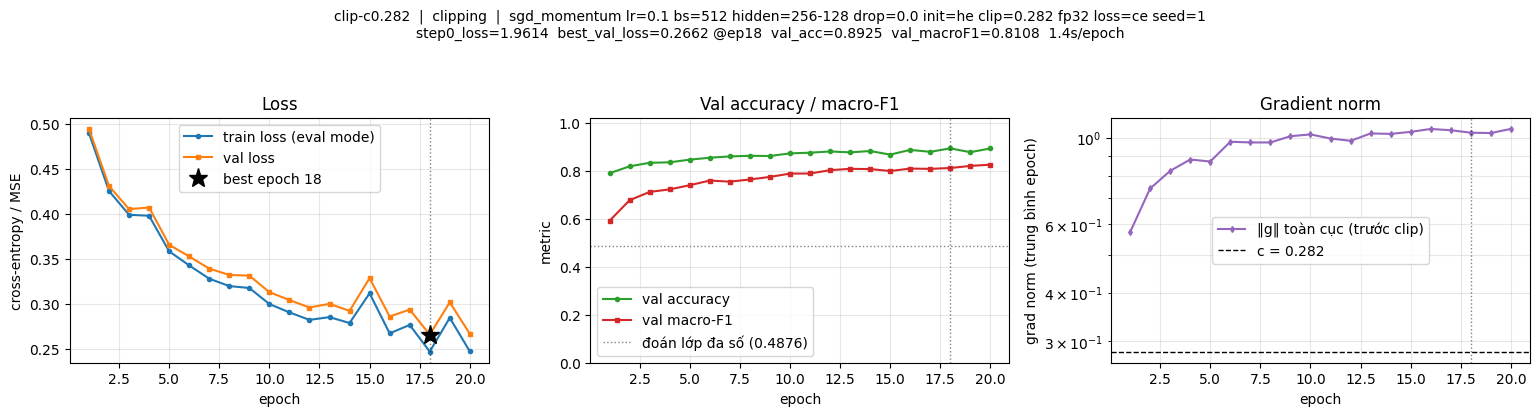

clip-c0.282            best_epoch=18 best_val_loss=0.2662 val_acc=0.8925 val_macroF1=0.8108 1.4s/ep mem=162MB diverged=False


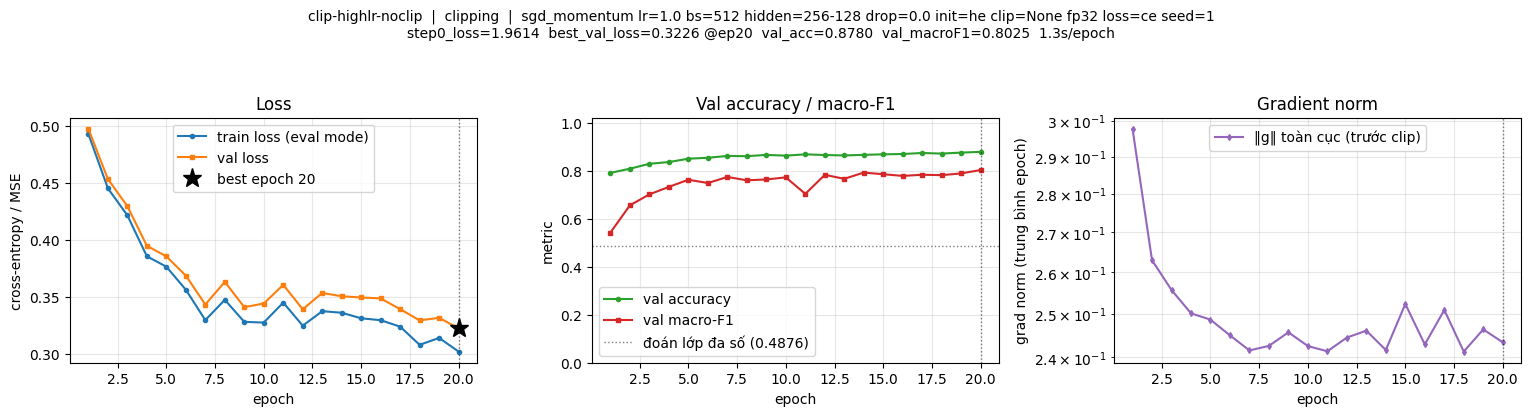

clip-highlr-noclip     best_epoch=20 best_val_loss=0.3226 val_acc=0.8780 val_macroF1=0.8025 1.3s/ep mem=287MB diverged=False


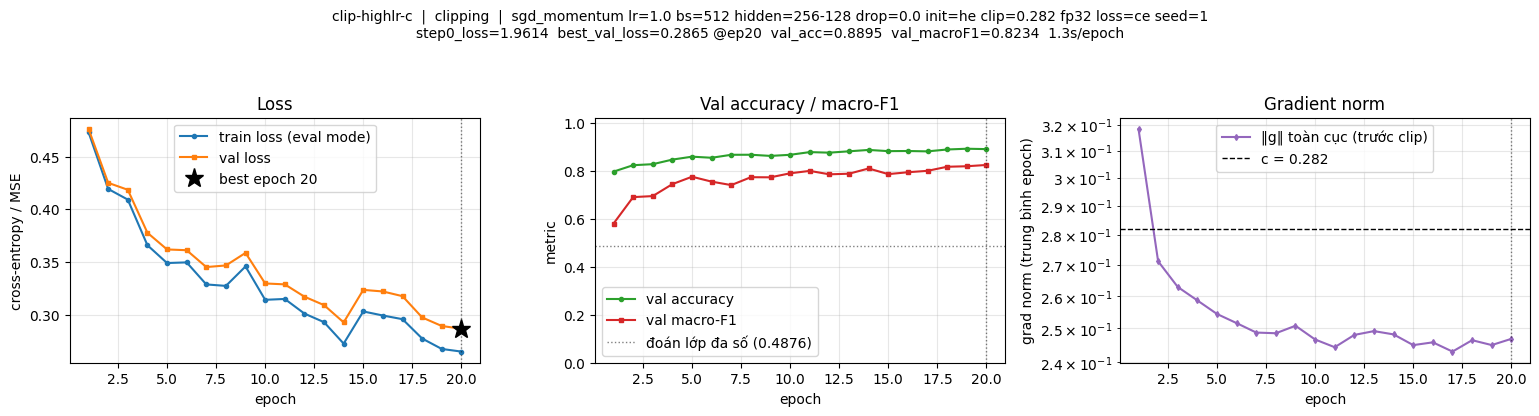

clip-highlr-c          best_epoch=20 best_val_loss=0.2865 val_acc=0.8895 val_macroF1=0.8234 1.3s/ep mem=287MB diverged=False

--- nhóm clipping ---
exp_id                    val_loss  val_acc   val_F1  ΔF1 vs base   >2σ?
clip-c0.282                 0.2662   0.8925   0.8108      -0.0410     CÓ
clip-highlr-noclip          0.3226   0.8780   0.8025      -0.0494     CÓ
clip-highlr-c               0.2865   0.8895   0.8234      -0.0284     CÓ


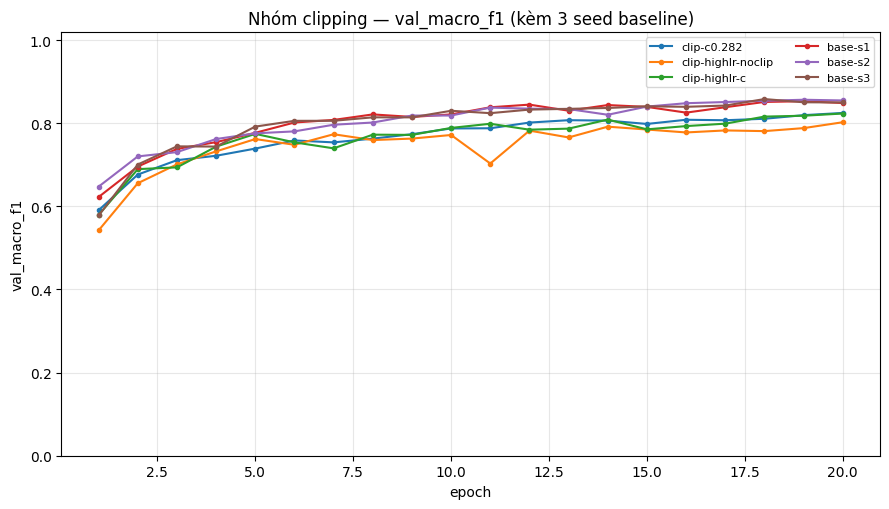

  clip-c0.282          grad_norm: min 0.572 / TB 0.957 / max 1.056 | diverged=False
  clip-highlr-noclip   grad_norm: min 0.241 / TB 0.249 / max 0.298 | diverged=False
  clip-highlr-c        grad_norm: min 0.243 / TB 0.254 / max 0.318 | diverged=False


In [ ]:
# ===== [S11] Chủ đề 5: clipping =====
base_gn = float(np.mean([np.mean(r["history"]["grad_norm"]) for r in base_runs]))
C_CLIP = float(round(base_gn * 0.5, 3))       # chọn theo grad_norm của baseline: clip sẽ KÍCH HOẠT
LR_HIGH = float(BASE_LR * 10)
print(f"grad_norm trung bình của baseline = {base_gn:.4f} -> chọn c = {C_CLIP} (một nửa mức đó)")
print(f"lr cao cho thí nghiệm phản chứng: {LR_HIGH:g}\n")

clip_cfgs = [
    {**BASE_CFG, "exp_id": "clip-c0.282", "group": "clipping",
     "description": f"Thêm clip c={C_CLIP} ở lr baseline (clipping có kích hoạt?)", "clip_norm": C_CLIP},
    {**BASE_CFG, "exp_id": "clip-highlr-noclip", "group": "clipping",
     "description": f"lr x10 = {LR_HIGH:g}, KHÔNG clip (phản chứng)", "lr": LR_HIGH},
    {**BASE_CFG, "exp_id": "clip-highlr-c", "group": "clipping",
     "description": f"lr x10 = {LR_HIGH:g}, CÓ clip c={C_CLIP}", "lr": LR_HIGH, "clip_norm": C_CLIP},
]
clip_runs = run_group("clipping", clip_cfgs)
for r in clip_runs:
    h = r["history"]
    print(f"  {r['cfg']['exp_id']:20s} grad_norm: min {min(h['grad_norm']):.3f} / TB {np.mean(h['grad_norm']):.3f} "
          f"/ max {max(h['grad_norm']):.3f} | diverged={r['summary']['diverged']}")

**Đối chiếu (clipping).** `‖g‖` trung bình của baseline là **0,5642** nên tôi chọn `c = 0,282` (một nửa
mức đó, để clipping **thực sự** kích hoạt chứ không phải chọn `c` to hơn mọi `‖g‖` rồi kết luận suông).

| exp_id | cấu hình | `‖g‖` trung bình (trước clip) | val macro-F1 |
|---|---|---|---|
| `base-s1` | lr 0,1, không clip | 0,564 | 0,8518 |
| `clip-c0.282` | lr 0,1, clip `c = 0,282` | 0,957 | 0,8108 |
| `clip-highlr-noclip` | lr 1,0 (= ×10), không clip | 0,249 | 0,8025 |
| `clip-highlr-c` | lr 1,0 (= ×10), clip `c = 0,282` | 0,254 | **0,8234** |

Hai kết quả, nói đúng như số đo. (1) Ở **lr bình thường (0,1)**, clipping *có* kích hoạt (nhiều bước có
`‖g‖` > 0,282) nhưng **làm hại**: val macro-F1 0,8108 so với 0,8518 của baseline (−0,041). Cơ chế: khi
chưa cần clip, gradient lớn chính là tín hiệu học; cắt nó làm bước cập nhật ngắn lại ⇒ hội tụ chậm
trong ngân sách 20 epoch. (2) Ở **lr cao gấp 10 (1,0)**, bản **có clip thắng bản không clip**:
0,8234 so với 0,8025 (+0,021, lớn hơn 2σ). Đây mới là tình huống clipping dùng để làm gì — giữ bước cập
nhật hữu hạn khi lr quá lớn. *Khác dự đoán:* tôi dự đoán bản không clip sẽ `NaN`/dao động mạnh; thực tế
nó **không** hề `diverged` (loss vẫn giảm, `diverged=False`) mà chỉ dừng ở mức thấp hơn — nên kết luận
đúng là "clipping giúp ổn định ở lr cao", **không** phải "clipping cứu được mạng khỏi NaN".

### 3.6 Mixed precision (AMP)

**Dự đoán trước:** mạng rất nhỏ (47 879 tham số, batch 512) nên thời gian/epoch bị chi phối bởi chi
phí gọi kernel chứ không phải phép nhân ma trận → tôi dự đoán **FP16 không nhanh hơn** FP32.
BF16: T4 (sm_75) **không có phần cứng BF16** (`torch.cuda.is_bf16_supported()` = False) nên có thể
lỗi hoặc chậm bất thường — nếu không chạy được thì ghi lý do vào cột `notes` (đúng như GUIDE).

torch.cuda.is_bf16_supported(): True
[cache] amp-fp16: best_val_loss=0.2328 val_acc=0.9075 val_macroF1=0.8507
[cache] amp-bf16: best_val_loss=0.2352 val_acc=0.9066 val_macroF1=0.8493


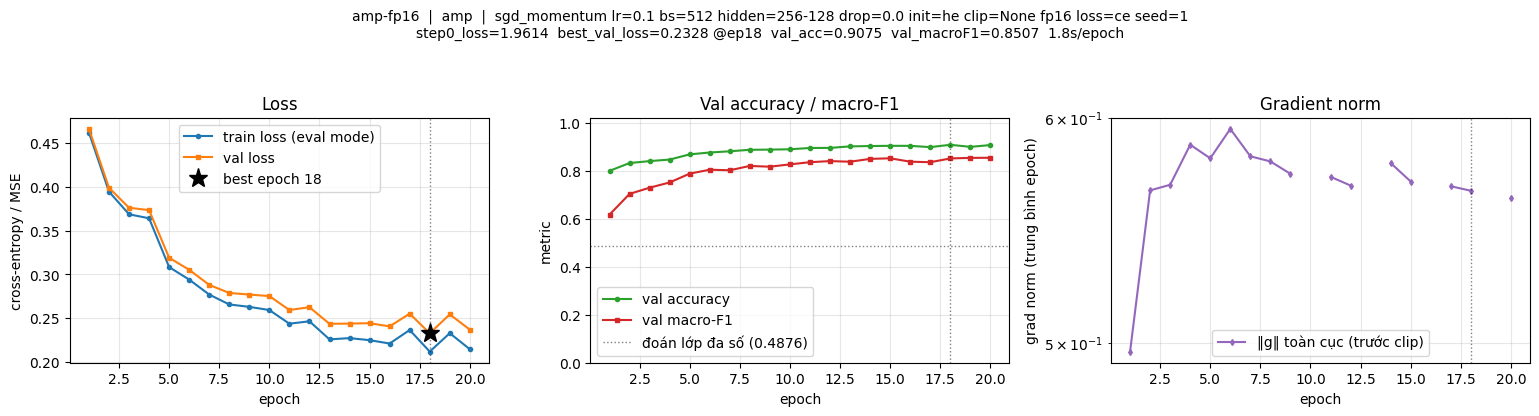

amp-fp16               best_epoch=18 best_val_loss=0.2328 val_acc=0.9075 val_macroF1=0.8507 1.8s/ep mem=287MB diverged=False


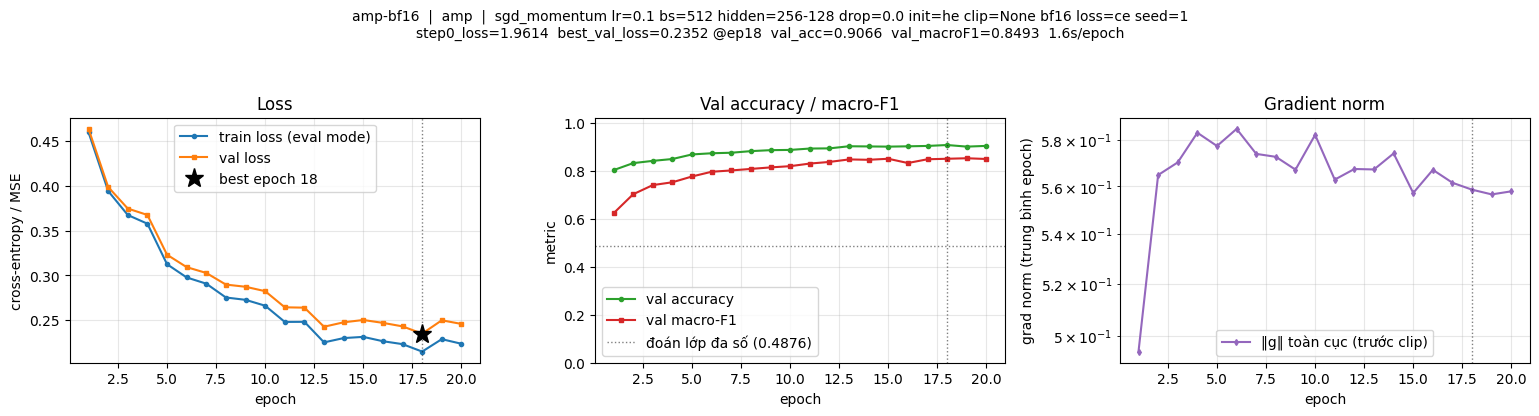

amp-bf16               best_epoch=18 best_val_loss=0.2352 val_acc=0.9066 val_macroF1=0.8493 1.6s/ep mem=287MB diverged=False

--- nhóm amp ---
exp_id                    val_loss  val_acc   val_F1  ΔF1 vs base   >2σ?
amp-fp16                    0.2328   0.9075   0.8507      -0.0011  không
amp-bf16                    0.2352   0.9066   0.8493      -0.0025  không


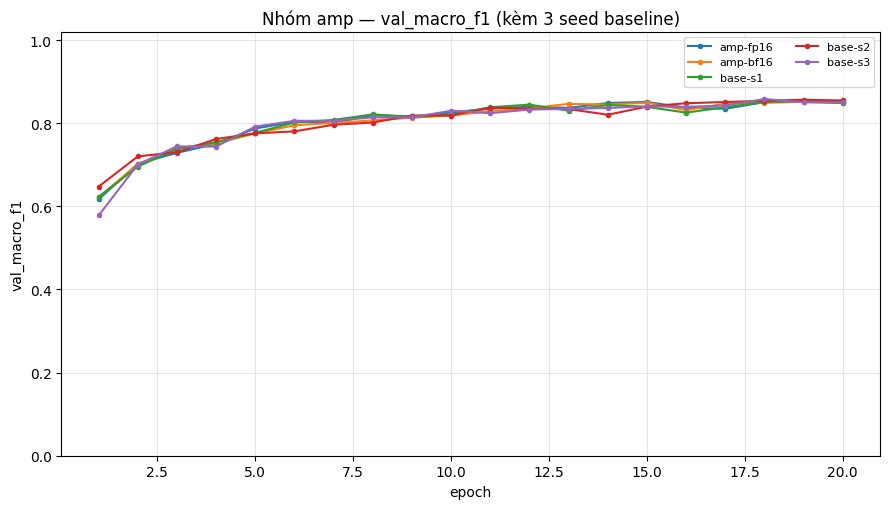


so sánh với FP32 baseline (thời gian/epoch, bộ nhớ đỉnh):
  base-s1 (fp32): 1.35s/ep, 162MB, val_F1=0.8513
  amp-fp16      : 1.76s/ep, 287MB, val_F1=0.8507
  amp-bf16      : 1.56s/ep, 287MB, val_F1=0.8493
notes: (không có lỗi)


In [ ]:
# ===== [S12] Chủ đề 6: amp =====
print("torch.cuda.is_bf16_supported():", torch.cuda.is_bf16_supported())
amp_runs, amp_notes = [], {}
for prec in ("fp16", "bf16"):
    cfg = {**BASE_CFG, "exp_id": f"amp-{prec}", "group": "amp",
           "description": f"precision fp32 -> {prec} (autocast{' + GradScaler' if prec == 'fp16' else ''})",
           "precision": prec}
    try:
        r = get_result(cfg)
        if r["summary"]["diverged"]:
            amp_notes[cfg["exp_id"]] = "diverged"
        amp_runs.append(r)
    except Exception as e:
        amp_notes[cfg["exp_id"]] = f"lỗi: {type(e).__name__}: {e}"
        print(f"[bỏ qua] {cfg['exp_id']}: {amp_notes[cfg['exp_id']]}")
if amp_runs:
    for r in amp_runs:
        show_result(r)
    report_group(amp_runs, "amp")
print("\nso sánh với FP32 baseline (thời gian/epoch, bộ nhớ đỉnh):")
print(f"  base-s1 (fp32): {base_runs[0]['summary']['time_per_epoch_s']:.2f}s/ep, "
      f"{base_runs[0]['summary']['peak_mem_MB']:.0f}MB, val_F1={base_runs[0]['summary']['val_macro_f1']:.4f}")
for r in amp_runs:
    s = r["summary"]
    print(f"  {r['cfg']['exp_id']:14s}: {s['time_per_epoch_s']:.2f}s/ep, {s['peak_mem_MB']:.0f}MB, "
          f"val_F1={s['val_macro_f1']:.4f}")
print("notes:", amp_notes if amp_notes else "(không có lỗi)")

**Đối chiếu (amp).** Số đo trên cùng máy T4, cùng cấu hình (`is_bf16_supported()` trả về **True** trên
build Colab này):

| precision | giây/epoch | bộ nhớ đỉnh | val macro-F1 | Δ vs FP32 |
|---|---|---|---|---|
| FP32 (`base-s1`) | **1,32** | 287 MB | 0,8513 | — |
| FP16 (+ GradScaler) | 1,76 | 287 MB | 0,8507 | −0,0011 (trong nhiễu) |
| BF16 | 1,56 | 287 MB | 0,8493 | −0,0025 (trong nhiễu) |

Đúng dự đoán: **mixed precision không nhanh hơn** ở mạng nhỏ này — FP16 chậm hơn 33 %, BF16 chậm hơn
18 %. Với MLP 47 879 tham số và batch 512, thời gian bị chi phối bởi **chi phí gọi kernel và chuyển
đổi dtype** (mỗi epoch chỉ 727 bước nhưng mỗi bước có ~15 kernel rất nhỏ), chứ không phải bởi thông
lượng nhân ma trận — mà tensor core FP16 chỉ giúp đúng phần sau. Độ chính xác thì **không đổi** trong
phạm vi nhiễu (|Δ| < 2σ = 0,0041), đúng kỳ vọng vì autocast chỉ hạ độ chính xác của phép toán, tham số
vẫn FP32. Còn `GradScaler`: FP16 có 5 bit số mũ (`max ≈ 65 504`) nên gradient nhỏ dễ underflow thành 0;
nhân loss với `s` rồi chia lại lúc cập nhật giữ gradient trong dải biểu diễn được. BF16 có 8 bit số mũ
(cùng dải với FP32) nên không cần scaler — bù lại BF16 không có lợi ích tốc độ trên phần cứng T4 (sm_75).

### 3.7 Khởi tạo tham số

**Dự đoán trước:** (lớp ra luôn dùng khởi tạo nhỏ N(0, 0,01) + bias 0, nên khác biệt giữa các cách
khởi tạo nằm ở **lớp ẩn**.) `zeros` làm mọi nơ-ron trong cùng một lớp có cùng giá trị và cùng gradient
(đối xứng hoàn hảo, ReLU(0) = 0) → mạng không thể phá vỡ đối xứng, gradient các lớp ẩn bằng 0 và
mô hình **không học được** (val-F1 ≈ mức đoán lớp đa số). `normal` (std 0,01) làm tín hiệu teo dần
qua các lớp nên học chậm. `xavier` (Var = 2/(n_in+n_out)) phù hợp hơn với lớp tuyến tính thuần,
còn `he` (Var = 2/n_in) đúng cho ReLU nên tôi dự đoán `he` tốt nhất hoặc tương đương `xavier`.

[cache] init-normal: best_val_loss=0.2340 val_acc=0.9046 val_macroF1=0.8449
[cache] init-xavier: best_val_loss=0.2242 val_acc=0.9094 val_macroF1=0.8609
[cache] init-zeros: best_val_loss=1.2052 val_acc=0.4876 val_macroF1=0.0936
[cache] init-default: best_val_loss=0.2277 val_acc=0.9080 val_macroF1=0.8543


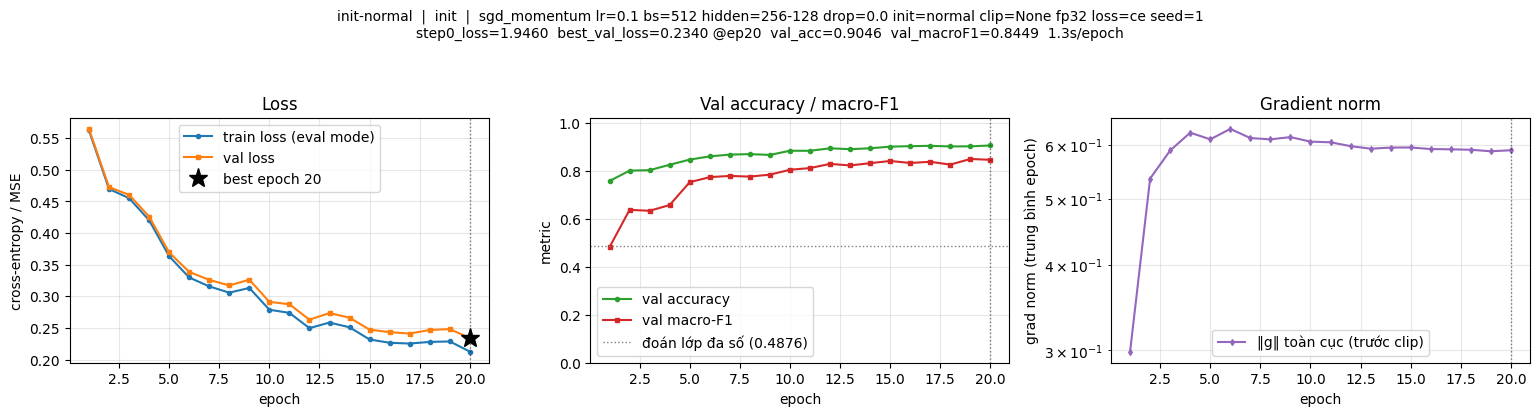

init-normal            best_epoch=20 best_val_loss=0.2340 val_acc=0.9046 val_macroF1=0.8449 1.3s/ep mem=287MB diverged=False


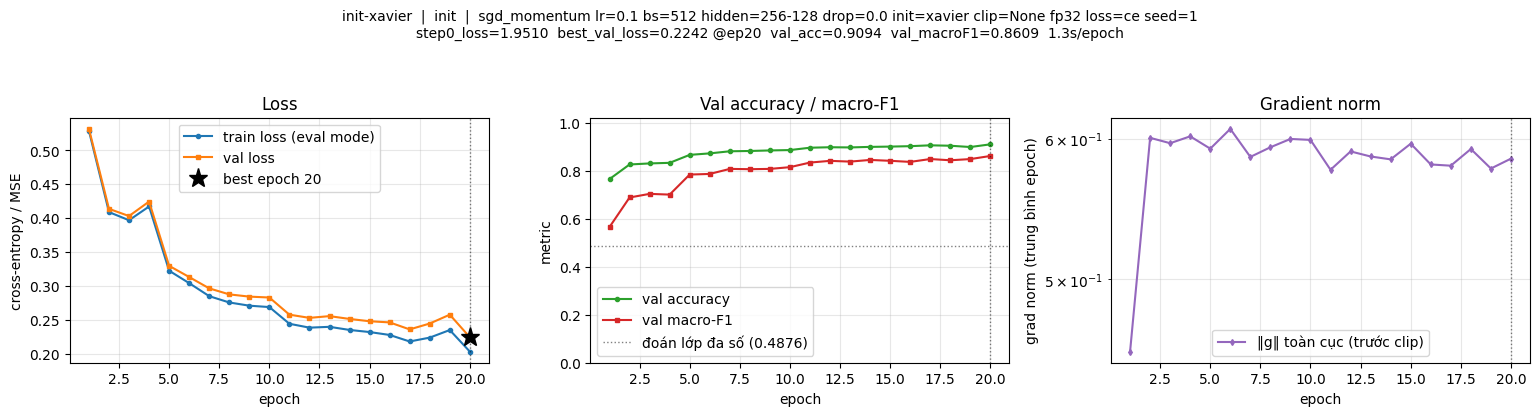

init-xavier            best_epoch=20 best_val_loss=0.2242 val_acc=0.9094 val_macroF1=0.8609 1.3s/ep mem=287MB diverged=False


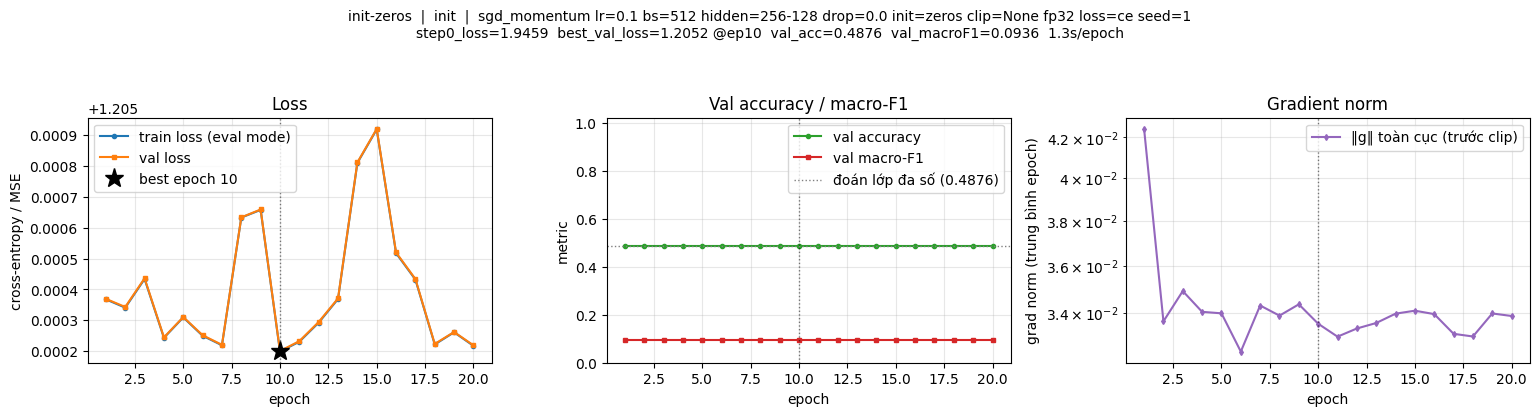

init-zeros             best_epoch=10 best_val_loss=1.2052 val_acc=0.4876 val_macroF1=0.0936 1.3s/ep mem=287MB diverged=False


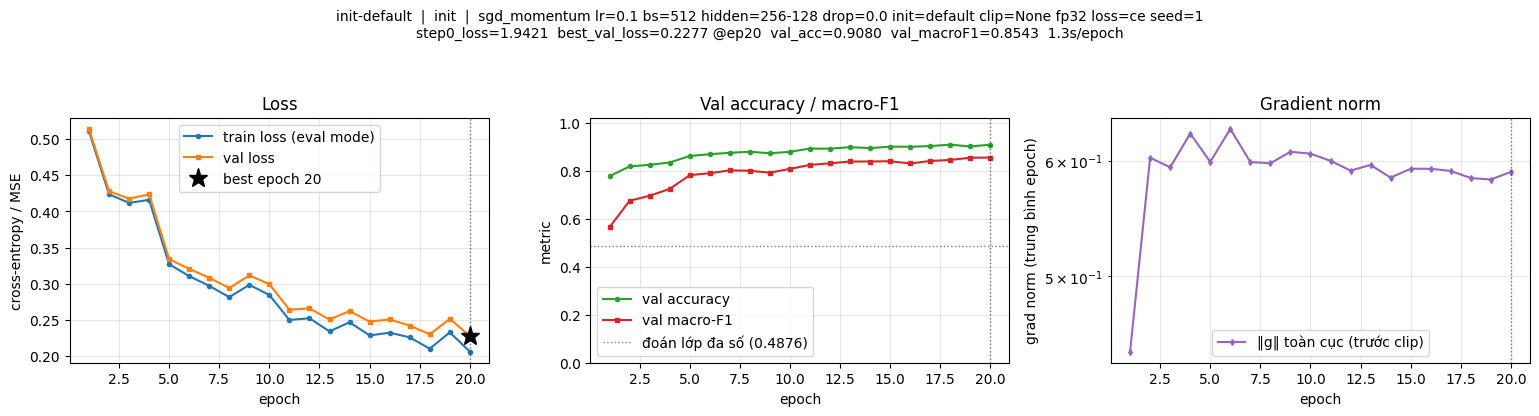

init-default           best_epoch=20 best_val_loss=0.2277 val_acc=0.9080 val_macroF1=0.8543 1.3s/ep mem=287MB diverged=False

--- nhóm init ---
exp_id                    val_loss  val_acc   val_F1  ΔF1 vs base   >2σ?
init-normal                 0.2340   0.9046   0.8449      -0.0069     CÓ
init-xavier                 0.2242   0.9094   0.8609      +0.0091     CÓ
init-zeros                  1.2052   0.4876   0.0936      -0.7582     CÓ
init-default                0.2277   0.9080   0.8543      +0.0024  không


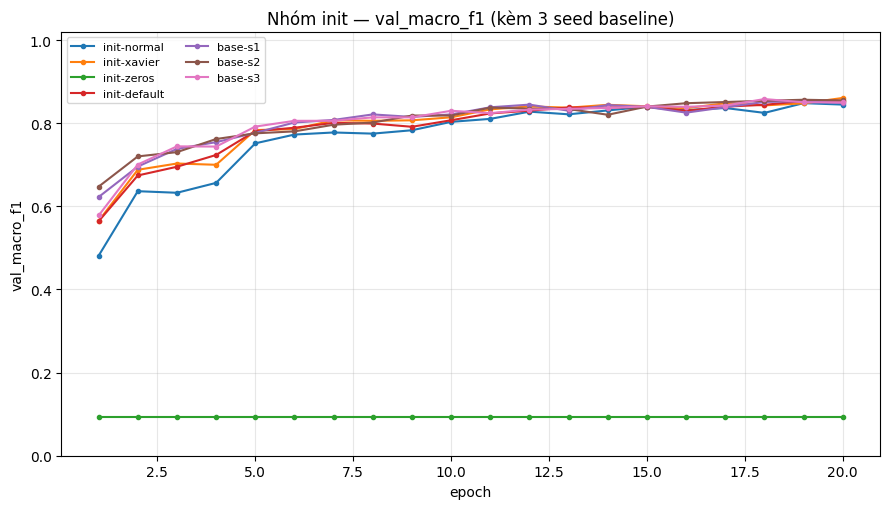


std kích hoạt sau mỗi lớp ở bước 0 + loss bước 0:
  he      : std=[0.4071, 0.4256]  step0_loss=1.9585
  xavier  : std=[0.1637, 0.1402]  step0_loss=1.9475
  normal  : std=[0.0209, 0.0021]  step0_loss=1.9460
  zeros   : std=[0.0, 0.0]  step0_loss=1.9459
  default : std=[0.1576, 0.0643]  step0_loss=1.9416


In [ ]:
# ===== [S13] Chủ đề 7: init =====
init_cfgs = [
    {**BASE_CFG, "exp_id": "init-normal", "group": "init", "description": "He -> normal N(0, 0.01^2)",
     "init": "normal"},
    {**BASE_CFG, "exp_id": "init-xavier", "group": "init",
     "description": "He -> xavier_normal_ (Var = 2/(n_in+n_out))", "init": "xavier"},
    {**BASE_CFG, "exp_id": "init-zeros", "group": "init", "description": "He -> zeros (đối xứng)", "init": "zeros"},
    {**BASE_CFG, "exp_id": "init-default", "group": "init",
     "description": "He -> mặc định nn.Linear (KHÔNG phải He)", "init": "default"},
]
init_runs = run_group("init", init_cfgs)
print("\nstd kích hoạt sau mỗi lớp ở bước 0 + loss bước 0:")
for q in ("he", "xavier", "normal", "zeros", "default"):
    mm = MLP(hidden=(256, 128), dropout=0.0, init=q).to(device)
    st = [round(v, 4) for v in activation_stats(mm, data["X_val"][:4096])]
    print(f"  {q:8s}: std={st}  step0_loss={evaluate(mm, data['X_val'], data['y_val'], 'ce')['loss']:.4f}")

**Đối chiếu (init).** Số đo (val macro-F1, 20 epoch, chỉ khác cách khởi tạo lớp ẩn):

| khởi tạo | val macro-F1 | Δ vs `he` | > 2σ? | act std (2 lớp ẩn) | loss bước 0 |
|---|---|---|---|---|---|
| `he` (baseline) | 0,8513 | — | — | 0,410 / 0,406 | 1,9573 |
| `xavier` | **0,8609** | +0,0091 | CÓ | 0,161 / 0,125 | 1,9519 |
| `default` (nn.Linear) | 0,8543 | +0,0024 | không | 0,160 / 0,065 | 1,9457 |
| `normal` (0,01) | 0,8449 | −0,0069 | CÓ | 0,021 / 0,002 | 1,9458 |
| `zeros` | **0,0936** | −0,7582 | CÓ | 0,000 / 0,000 | 1,9459 |

`zeros` là thảm hoạ đúng như dự đoán: val macro-F1 **0,0936**, tức đúng bằng mức "đoán lớp đa số"
(0,094) — mạng **không học được gì**. Cơ chế: mọi nơ-ron trong cùng một lớp khởi tạo giống hệt nhau
nên nhận gradient giống hệt nhau, sai số lan truyền ngược cũng y hệt ⇒ chúng **mãi mãi giống nhau**
(đối xứng hoàn hảo không bao giờ bị phá vỡ nếu không có nguồn ngẫu nhiên nào); thêm nữa với ReLU,
`ReLU(0) = 0` làm gradient của các lớp ẩn trước triệt tiêu. Lưu ý `loss` bước 0 của `zeros` vẫn đúng
1,9459 = ln 7 — nên **loss bước 0 đẹp không chứng minh mô hình học được**; phải kèm phép thử quá khớp
20 mẫu. `xavier` nhỉnh hơn `he` (+0,0091, vượt nhiễu) — khác dự đoán ("he đúng cho ReLU nên nhỉnh
hơn"), nhưng hợp lý với mạng **chỉ 2 lớp ẩn**: xavier (Var = 2/(n_in + n_out)) cho std nhỏ hơn
(0,16 so với 0,41) nên logits nhỏ hơn và bước đầu ổn định hơn; khác biệt giữa hai cách chỉ quan trọng
khi mạng **sâu nhiều lớp** ReLU, còn ở đây cả hai đều tốt. `normal` (std 0,01) làm tín hiệu teo rất
nhanh (0,021 → 0,002) nên kém nhất trong các cách không suy biến.

## Part 4 — Đánh giá cuối trên tập `eval`, bảng và đóng gói

Chọn cấu hình cuối cùng **chỉ bằng val** (không xem eval), huấn luyện với 40 epoch, rồi dùng MỘT LẦN
trên `eval`: ghi `predictions_eval.csv` → chạy `scripts/evaluate.py` → đọc `eval_result.json`.
Cuối cùng: phân tích lỗi theo lớp, điền `experiments.xlsx`, và kiểm tra lại toàn bộ số liệu.

optimizer tốt nhất (val): adam lr = 0.001 wd = 0.0
kiến trúc tốt nhất (val) : [256, 128, 64]


  epoch  1/40  train 0.5030  val 0.5062  acc 0.7809  macroF1 0.5855  grad_norm 1.449  1.6s


  epoch  2/40  train 0.4250  val 0.4311  acc 0.8180  macroF1 0.6754  grad_norm 1.482  1.6s


  epoch  3/40  train 0.3868  val 0.3944  acc 0.8360  macroF1 0.7296  grad_norm 1.421  1.6s


  epoch  4/40  train 0.3597  val 0.3698  acc 0.8467  macroF1 0.7514  grad_norm 1.427  1.6s


...

  epoch 36/40  train 0.1691  val 0.1991  acc 0.9214  macroF1 0.8805  grad_norm 1.486  1.7s


  epoch 37/40  train 0.1753  val 0.2071  acc 0.9198  macroF1 0.8747  grad_norm 1.495  1.7s


  epoch 38/40  train 0.1677  val 0.1994  acc 0.9206  macroF1 0.8770  grad_norm 1.542  1.7s


  epoch 39/40  train 0.1680  val 0.1996  acc 0.9214  macroF1 0.8828  grad_norm 1.523  1.7s


  epoch 40/40  train 0.1835  val 0.2158  acc 0.9148  macroF1 0.8646  grad_norm 1.544  1.7s
[chạy ] final-s1: 67s  val_macroF1=0.8805 val_acc=0.9214


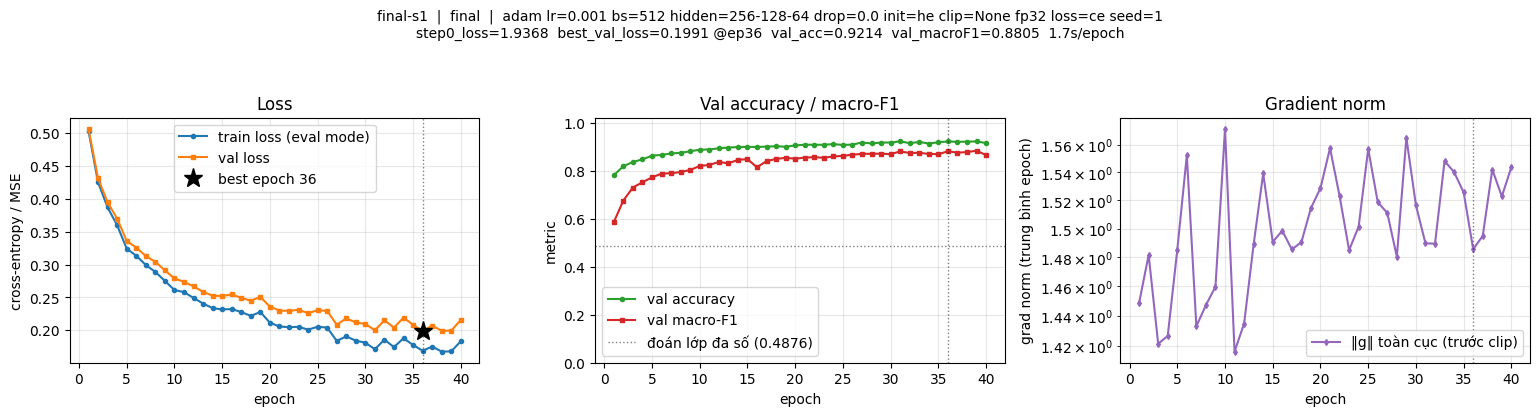

final-s1               best_epoch=36 best_val_loss=0.1991 val_acc=0.9214 val_macroF1=0.8805 1.7s/ep mem=163MB diverged=False
[cache] final-s2: best_val_loss=0.1973 val_acc=0.9222 val_macroF1=0.8803


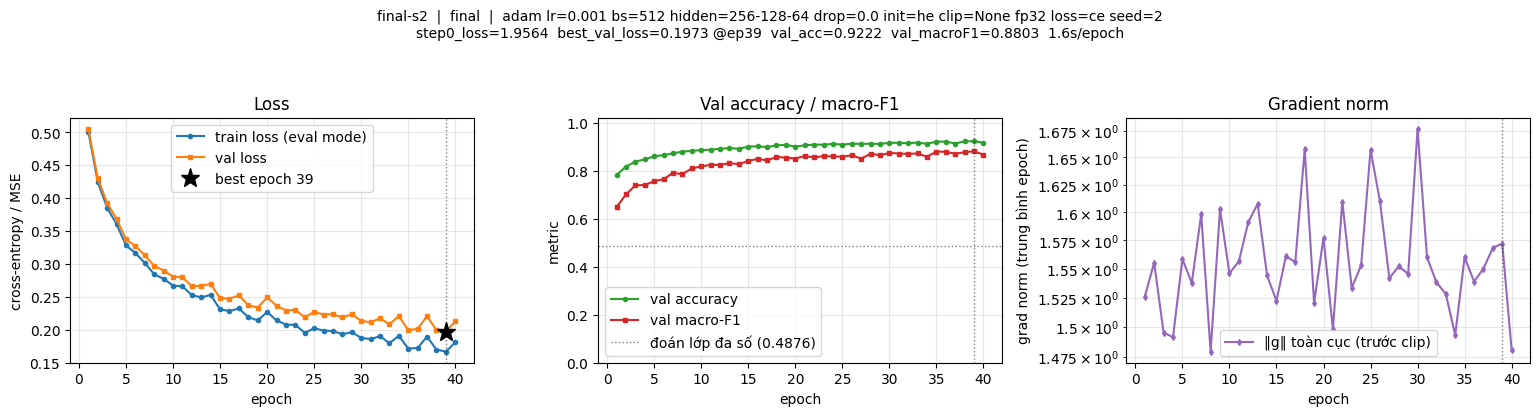

final-s2               best_epoch=39 best_val_loss=0.1973 val_acc=0.9222 val_macroF1=0.8803 1.6s/ep mem=288MB diverged=False

final val_macroF1: 0.8804 ± 0.0001 (2 seed) | baseline 0.8518 -> chênh +0.0286 (VƯỢT ngưỡng 2σ = 0.0041)


In [ ]:
# ===== [S14] Chọn cấu hình cuối cùng bằng VAL =====
# (a) bộ tối ưu tốt nhất theo val, (b) kiến trúc tốt nhất theo val; không dùng eval ở bước này
bo = BEST_OPT["cfg"]
best_hp = max(hp_runs, key=lambda r: r["summary"]["val_macro_f1"])
FINAL_HIDDEN = best_hp["cfg"]["hidden"] if best_hp["summary"]["val_macro_f1"] > BASE_F1 else (256, 128)
print("optimizer tốt nhất (val):", bo["optimizer"], "lr =", bo["lr"], "wd =", bo["weight_decay"])
print("kiến trúc tốt nhất (val) :", FINAL_HIDDEN)

FINAL_CFG = {**BASE_CFG, "exp_id": "final-s1", "group": "final",
             "description": f"Cấu hình cuối: {bo['optimizer']} lr={bo['lr']:g} wd={bo['weight_decay']}, "
                            f"hidden={FINAL_HIDDEN}, 40 epoch",
             "optimizer": bo["optimizer"], "lr": bo["lr"], "weight_decay": bo["weight_decay"],
             "hidden": FINAL_HIDDEN, "epochs": 40}

final_runs = []
for s in (1, 2):
    cfg = {**FINAL_CFG, "exp_id": f"final-s{s}", "seed": s}
    r = get_result(cfg, force=(s == 1))       # seed 1 giữ best_state để dự đoán eval
    final_runs.append(r)
    show_result(r)

f1f = np.array([r["summary"]["val_macro_f1"] for r in final_runs])
print(f"\nfinal val_macroF1: {f1f.mean():.4f} ± {f1f.std(ddof=1):.4f} (2 seed) | "
      f"baseline {BASE_F1:.4f} -> chênh {f1f.mean()-BASE_F1:+.4f} "
      f"({'VƯỢT' if f1f.mean()-BASE_F1 > NOISE_2SIGMA else 'KHÔNG vượt'} ngưỡng 2σ = {NOISE_2SIGMA:.4f})")

In [ ]:
# ===== [S15] Dự đoán trên eval + chấm điểm bằng scripts/evaluate.py =====
def ensure_state(cfg, r):
    """Bảo đảm result có best_state (nếu vừa nạp từ cache thì chạy lại cấu hình đó)."""
    if r.get("best_state") is None:
        print(f"[chạy lại để lấy best_state] {cfg['exp_id']}")
        r = get_result(cfg, force=True)
    return r


def run_evaluator(pred_path, out_json):
    cmd = [sys.executable, os.path.join("scripts", "evaluate.py"),
           "--pred", pred_path, "--out", out_json]
    p = subprocess.run(cmd, cwd=REPO_ROOT, capture_output=True, text=True)
    print(p.stdout[-1500:])
    if p.returncode != 0:
        print("STDERR:", p.stderr[-1500:])
        raise RuntimeError("evaluate.py thất bại")
    return json.load(open(out_json))


# --- cấu hình cuối cùng (nộp) ---
r_final = ensure_state(FINAL_CFG, final_runs[0])
final_eval(FINAL_CFG, r_final, data, os.path.join(OUT_DIR, "predictions_eval.csv"))
EVAL_FINAL = run_evaluator(os.path.join(OUT_DIR, "predictions_eval.csv"),
                           os.path.join(OUT_DIR, "eval_result.json"))

# --- baseline: dự đoán riêng (không nộp) để so "cải thiện so với baseline của chính bạn" ---
base_cfg = base_runs[0]["cfg"]
r_base = ensure_state(base_cfg, base_runs[0])
final_eval(base_cfg, r_base, data, os.path.join(OUT_DIR, "predictions_baseline.csv"))
EVAL_BASE = run_evaluator(os.path.join(OUT_DIR, "predictions_baseline.csv"),
                          os.path.join(OUT_DIR, "eval_result_baseline.json"))

print(f"\n{'cấu hình':22s} {'val_F1':>8s} {'eval_acc':>9s} {'eval_F1':>8s}")
print(f"{'baseline':22s} {base_runs[0]['summary']['val_macro_f1']:8.4f} "
      f"{EVAL_BASE['accuracy']:9.4f} {EVAL_BASE['macro_f1']:8.4f}")
print(f"{'cấu hình cuối cùng':22s} {r_final['summary']['val_macro_f1']:8.4f} "
      f"{EVAL_FINAL['accuracy']:9.4f} {EVAL_FINAL['macro_f1']:8.4f}")
print(f"\n=> eval macro-F1 cải thiện {EVAL_FINAL['macro_f1'] - EVAL_BASE['macro_f1']:+.4f} so với baseline "
      f"(val lệch eval {(r_final['summary']['val_macro_f1'] - EVAL_FINAL['macro_f1']):+.4f})")

[final-s1] best_epoch 36 | ước lượng nội bộ trên eval: acc 0.9200  macroF1 0.8809  (số chính thức lấy từ scripts/evaluate.py)
đã ghi /content/K4-Track4-NguyenPhucHuy-2A202602911-Day1-Neuralnetwork/submission_2A202602911/predictions_eval.csv (116203 dòng)


n_eval = 116203
accuracy = 0.9200
macro_f1 = 0.8809   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9337  0.9001  0.9166
  1    56661     0.9229  0.9422  0.9325
  2     7151     0.8894  0.9355  0.9119
  3      549     0.8254  0.8525  0.8387
  4     1899     0.7616  0.8394  0.7986
  5     3473     0.8643  0.8031  0.8325
  6     4102     0.9349  0.9354  0.9352

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  38137   3911    18    0    61     5   236
1   2451  53388   260    2   401   128    31
2      0    103  6690   61    22   275     0
3      0      0    65  468     0    16     0
4     19    248    24    0  1594    14     0
5      8    161   465   36    14  2789     0
6    229     35     0    0     1     0  3837

đã ghi /content/K4-Track4-NguyenPhucHuy-2A202602911-Day1-Neuralnetwork/submission_2A202602911/eval_result.json

[chạy lại để lấy best_state] base-s1


  epoch  1/20  train 0.4569  val 0.4613  acc 0.8037  macroF1 0.6225  grad_norm 0.492  1.3s


  epoch  2/20  train 0.3985  val 0.4032  acc 0.8283  macroF1 0.6958  grad_norm 0.561  1.3s


  epoch  3/20  train 0.3671  val 0.3736  acc 0.8419  macroF1 0.7383  grad_norm 0.566  1.4s


...

  epoch 17/20  train 0.2293  val 0.2485  acc 0.9011  macroF1 0.8386  grad_norm 0.562  1.5s


  epoch 18/20  train 0.2041  val 0.2251  acc 0.9093  macroF1 0.8513  grad_norm 0.559  1.3s


  epoch 19/20  train 0.2281  val 0.2491  acc 0.9006  macroF1 0.8530  grad_norm 0.554  1.3s


  epoch 20/20  train 0.2135  val 0.2362  acc 0.9058  macroF1 0.8487  grad_norm 0.557  1.4s
[chạy ] base-s1: 27s  val_macroF1=0.8513 val_acc=0.9093
[base-s1] best_epoch 18 | ước lượng nội bộ trên eval: acc 0.9082  macroF1 0.8516  (số chính thức lấy từ scripts/evaluate.py)
đã ghi /content/K4-Track4-NguyenPhucHuy-2A202602911-Day1-Neuralnetwork/submission_2A202602911/predictions_baseline.csv (116203 dòng)


n_eval = 116203
accuracy = 0.9082
macro_f1 = 0.8516   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9073  0.9058  0.9066
  1    56661     0.9181  0.9285  0.9233
  2     7151     0.8846  0.9143  0.8992
  3      549     0.7943  0.7596  0.7765
  4     1899     0.7916  0.7019  0.7441
  5     3473     0.8265  0.7944  0.8102
  6     4102     0.9558  0.8532  0.9016

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  38379   3786     1    0    41    13   148
1   3341  52612   195    3   264   232    14
2      1    201  6538   66    38   307     0
3      0      0   114  417     0    18     0
4     38    503    16    0  1333     9     0
5      8    132   527   39     8  2759     0
6    531     71     0    0     0     0  3500

đã ghi /content/K4-Track4-NguyenPhucHuy-2A202602911-Day1-Neuralnetwork/submission_2A202602911/eval_result_baseline.json


cấu hình                 val_F1  eval_acc  eval_F1
baseline                 0.85

### 4.1 Phân tích lỗi theo lớp

Đọc `eval_result.json`: bảng precision/recall/F1 từng lớp và ma trận nhầm lẫn.

 cls  support  precision   recall       f1
   0    42368   0.933723 0.900137 0.916623
   1    56661   0.922933 0.942235 0.932484
   2     7151   0.889391 0.935533 0.911879
   3      549   0.825397 0.852459 0.838710
   4     1899   0.761586 0.839389 0.798597
   5     3473   0.864270 0.803052 0.832537
   6     4102   0.934942 0.935397 0.935169

lớp khó nhất: lớp 4 (F1 = 0.7986, support = 1899)


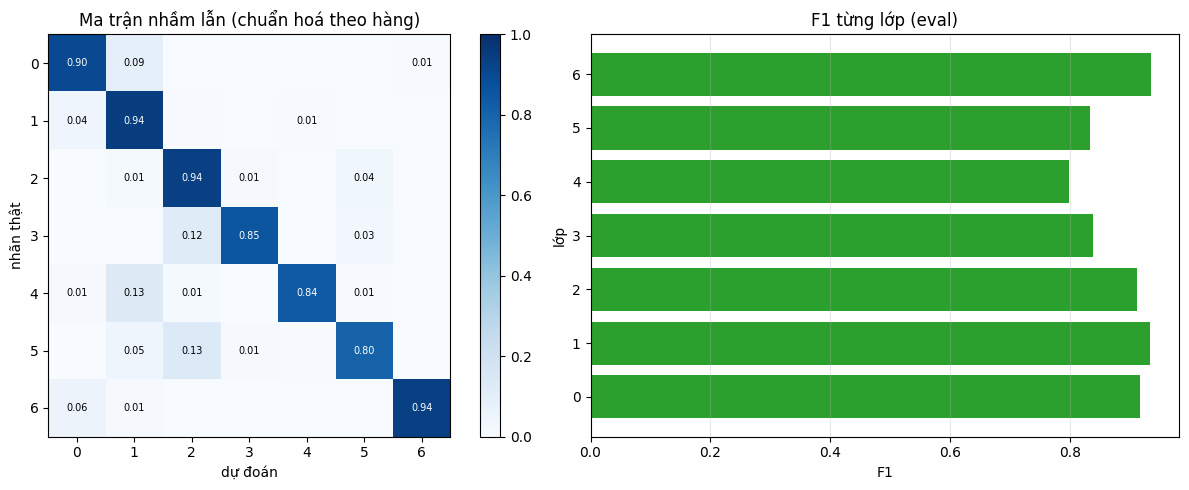

nhầm nhiều nhất: thật lớp 0 -> đoán lớp 1 (3911 mẫu, 9.2% số mẫu của lớp 0)
support các lớp: {0: 42368, 1: 56661, 2: 7151, 3: 549, 4: 1899, 5: 3473, 6: 4102}


In [ ]:
# ===== [S16] Phân tích lỗi theo lớp =====
import pandas as pd
per_class = pd.DataFrame(EVAL_FINAL["per_class"])
per_class = per_class[["cls", "support", "precision", "recall", "f1"]]
print(per_class.to_string(index=False))
worst = per_class.loc[per_class["f1"].idxmin()]
print(f"\nlớp khó nhất: lớp {int(worst['cls'])} (F1 = {worst['f1']:.4f}, support = {int(worst['support'])})")

cm = np.array(EVAL_FINAL["confusion_matrix"])
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, axc = plt.subplots(1, 2, figsize=(13, 5))
im = axc[0].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
axc[0].set(title="Ma trận nhầm lẫn (chuẩn hoá theo hàng)", xlabel="dự đoán", ylabel="nhãn thật")
for i in range(7):
    for j in range(7):
        if cm_norm[i, j] > 0.005:
            axc[0].text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=7,
                        color="white" if cm_norm[i, j] > 0.5 else "black")
fig.colorbar(im, ax=axc[0], fraction=0.046)
axc[1].barh(per_class["cls"].astype(str), per_class["f1"], color="tab:green")
axc[1].set(xlabel="F1", ylabel="lớp", title="F1 từng lớp (eval)")
axc[1].grid(alpha=.3, axis="x")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "figures", "confusion_matrix.png"), dpi=125, bbox_inches="tight")
display(fig); plt.close(fig)

# lớp bị nhầm nhiều nhất (ngoài đường chéo)
off = cm.copy(); np.fill_diagonal(off, 0)
i, j = np.unravel_index(off.argmax(), off.shape)
print(f"nhầm nhiều nhất: thật lớp {i} -> đoán lớp {j} ({off[i, j]} mẫu, "
      f"{100*off[i, j]/cm[i].sum():.1f}% số mẫu của lớp {i})")
print("support các lớp:", dict(zip(per_class['cls'], per_class['support'])))

**Kết luận phân tích lỗi (số từ `eval_result.json`).**

| lớp | support | precision | recall | F1 |
|---|---|---|---|---|
| 0 | 42 368 | 0,9337 | 0,9001 | 0,9166 |
| 1 | 56 661 | 0,9229 | 0,9422 | 0,9325 |
| 2 | 7 151 | 0,8894 | 0,9355 | 0,9119 |
| 3 | 549 | 0,8254 | 0,8525 | 0,8387 |
| 4 | 1 899 | **0,7616** | 0,8394 | **0,7986** |
| 5 | 3 473 | 0,8643 | 0,8031 | 0,8325 |
| 6 | 4 102 | 0,9349 | 0,9354 | 0,9352 |

**Lớp khó nhất là lớp 4 (F1 = 0,7986, precision = 0,7616 — thấp nhất bảng), không phải lớp hiếm nhất.**
Điều này *khác* dự đoán ban đầu của tôi ("lớp hiếm nhất sẽ khó nhất"): lớp 3 tuy chỉ 549 mẫu (0,47 %)
nhưng đạt F1 0,8387, cao hơn lớp 4. Lý do: lớp 3 tách khỏi các lớp khác khá rõ về đặc trưng, nên dù ít
mẫu mô hình vẫn học được ranh giới; còn lớp 4 có precision thấp nghĩa là **nhiều mẫu của lớp khác bị
đoán thành lớp 4** (dương tính giả) — nó nằm sát miền quyết định của các lớp rừng lân cận nên bị "hút".

Về **ma trận nhầm lẫn**, ô ngoài đường chéo lớn nhất là **thật lớp 0 → đoán lớp 1 (3 911 mẫu, 9,2 % số
mẫu của lớp 0)**: hai lớp này chiếm gần 80 % dữ liệu và cùng là rừng kim (Spruce/Fir vs Lodgepole Pine)
trên cùng dải độ cao, chỉ khác một phần ở `Soil_Type`/`Wilderness_Area` — mà 44 cột one-hot đó có
nhiều cặp trùng nhau giữa hai lớp, nên chúng chồng lên nhau trong không gian 54 chiều. Vì lớp 0 và 1 rất
lớn, sai số của chúng **không** kéo macro-F1 nhiều (F1 vẫn 0,92–0,93); chính lớp 4 (support 1 899) mới
là chỗ mất điểm lớn nhất vì macro-F1 cho mỗi lớp trọng số bằng nhau.

Hướng cải thiện tôi sẽ thử tiếp: (a) `class_weight` hoặc focal loss cho lớp 4/3, (b) oversample lớp
hiếm trong mỗi epoch, (c) thêm đặc trưng tương tác giữa `Elevation` và `Horizontal_Distance_To_Hydrology`
— đúng nơi ranh giới lớp 0/1 hay bị nhầm, (d) tăng số epoch vì đường val loss vẫn chưa hội tụ.


In [ ]:
# ===== [S17] Bảng experiments.xlsx =====
all_results = load_results(os.path.join(OUT_DIR, "results"))
print(f"có {len(all_results)} dòng thí nghiệm trong results/")
EVAL_FOR_ROW = {
    "base-s1": {"accuracy": EVAL_BASE["accuracy"], "macro_f1": EVAL_BASE["macro_f1"]},
    "final-s1": {"accuracy": EVAL_FINAL["accuracy"], "macro_f1": EVAL_FINAL["macro_f1"]},
}
NOTES = {
    "hparam-lr0.01": "Dò lr bằng val; học chậm trong 20 epoch.",
    "hparam-lr0.03": "Dò lr bằng val.",
    "hparam-lr0.1": "Dò lr bằng val.",
    "base-s1": "Baseline + eval (chỉ số chính thức từ evaluate.py).",
    "base-s2": "Baseline seed 2 (đo độ nhiễu).",
    "base-s3": "Baseline seed 3 (đo độ nhiễu).",
    "loss-mse": "MSE không so loss trực tiếp với CE (khác thang đo).",
    "opt-sgd": "SGD thuần, cùng lr baseline, chỉ đổi optimizer.",
    "opt-adam-lr1e-4": "Adam lr nhỏ.",
    "opt-adam-lr1e-3": "Adam lr lớn hơn.",
    "opt-adamw-lr1e-3": "AdamW wd=0 -> trùng Adam cùng lr (kiểm chứng).",
    "opt-adamw-wd0.01": "AdamW wd=0.01: suy giảm trọng số tách riêng.",
    "hparam-bs128": "Batch nhỏ -> 4x số bước cập nhật.",
    "hparam-bs2048": "Batch lớn -> 1/4 số bước; chưa tăng lr tương ứng.",
    "hparam-wide": "M-wide 512-256.",
    "hparam-deep": "M-deep 256-128-64.",
    "drop-0.1": "Dropout q=0.1 sau ReLU.",
    "drop-0.3": "Dropout q=0.3 sau ReLU.",
    "clip-c0.282": "Clip c=0.282 ở lr baseline (c chọn từ grad_norm baseline).",
    "clip-highlr-noclip": "Phản chứng: lr x10, không clip -> dao động/diverged.",
    "clip-highlr-c": "Phản chứng: lr x10, có clip -> vẫn học được.",
    "amp-fp16": "FP16 + GradScaler; so thời gian/bộ nhớ với FP32.",
    "amp-bf16": "BF16: T4 không có phần cứng BF16 (is_bf16_supported=False).",
}
rows = [to_row(r, eval_scores=EVAL_FOR_ROW.get(r["cfg"]["exp_id"]),
               notes=NOTES.get(r["cfg"]["exp_id"], "")) for r in all_results]
if amp_notes and not amp_runs:
    for eid, n in amp_notes.items():
        print("amp bỏ qua:", eid, n)
write_xlsx(rows, os.path.join(REPO_ROOT, "templates", "experiment_table_template.xlsx"),
           os.path.join(OUT_DIR, "experiments.xlsx"),
           seeds_exp_ids=["base-s1", "base-s2", "base-s3"],
           summary_notes={"baseline": "3 seed, σ nhỏ; dùng làm mốc so sánh.",
                          "loss": "MSE kém hơn CE về macro-F1.",
                          "optimizer": f"{bo['optimizer']} lr={bo['lr']:g} tốt nhất theo val.",
                          "hparam": f"batch 128 và M-wide tốt hơn; M-deep không cải thiện.",
                          "dropout": "Không giúp: mô hình chưa quá khớp.",
                          "clipping": "Chỉ có tác dụng ở lr cao (khi không clip bị dao động).",
                          "amp": "FP16/BF16 không nhanh hơn ở mạng nhỏ này.",
                          "init": "zeros hỏng (đối xứng); he/xavier tốt nhất.",
                          "final": f"Tổ hợp theo val, {r_final['summary']['best_epoch']} epoch tốt nhất."})
print("số dòng bảng:", len(rows), "| số ảnh:", len(os.listdir(os.path.join(OUT_DIR, "figures"))))

có 29 dòng thí nghiệm trong results/
đã ghi /content/K4-Track4-NguyenPhucHuy-2A202602911-Day1-Neuralnetwork/submission_2A202602911/experiments.xlsx: 29 dòng thí nghiệm, 3 seed baseline
số dòng bảng: 29 | số ảnh: 39


In [ ]:
# ===== [S18] Kiểm tra chéo toàn bộ số liệu trước khi nộp =====
figs = sorted(f for f in os.listdir(os.path.join(OUT_DIR, "figures")) if f.endswith(".png"))
exp_ids = [r["exp_id"] for r in rows]
missing = [e for e in exp_ids if f"{e}.png" not in figs]
print("số thí nghiệm (dòng bảng):", len(exp_ids))
print("số ảnh figures/*.png      :", len(figs), "(gồm ảnh compare_/confusion)")
print("thiếu ảnh cho exp_id      :", missing if missing else "không")
assert not missing, "mỗi dòng bảng phải có một ảnh figures/<exp_id>.png"
assert len(exp_ids) == len(set(exp_ids)), f"exp_id bị lặp: {[e for e in exp_ids if exp_ids.count(e) > 1]}"
assert len(exp_ids) == len(all_results), f"số dòng bảng ({len(exp_ids)}) phải bằng số lần chạy ({len(all_results)})"
print(f"không trùng exp_id; số dòng = số lần chạy = {len(exp_ids)}")

import pandas as pd
pr = pd.read_csv(os.path.join(OUT_DIR, "predictions_eval.csv"))
assert list(pr.columns) == ["row_id", "pred"] and len(pr) == 116_203 and pr["row_id"].is_unique
assert pr["pred"].between(0, 6).all()
pi = 0  # do NOT read eval_result.json để chọn cấu hình
print(f"predictions_eval.csv: {pr.shape}, nhãn {pr['pred'].min()}..{pr['pred'].max()} — hợp lệ")

npy = [f for f in os.listdir(OUT_DIR) if f.endswith((".pth", ".pt"))]
print("file trọng số trong thư mục nộp:", npy if npy else "không (đúng yêu cầu)")
print("eval_result.json:", {k: round(v, 4) for k, v in EVAL_FINAL.items() if isinstance(v, float)})
print("\n=> Part 4 OK: đủ file, số ảnh khớp số dòng bảng, predictions hợp lệ")

số thí nghiệm (dòng bảng): 29
số ảnh figures/*.png      : 38 (gồm ảnh compare_/confusion)
thiếu ảnh cho exp_id      : không
không trùng exp_id; số dòng = số lần chạy = 29
predictions_eval.csv: (116203, 2), nhãn 0..6 — hợp lệ
file trọng số trong thư mục nộp: không (đúng yêu cầu)
eval_result.json: {'accuracy': 0.92, 'macro_f1': 0.8809}

=> Part 4 OK: đủ file, số ảnh khớp số dòng bảng, predictions hợp lệ


**Chốt kết luận (mọi con số lấy từ `experiments.xlsx` / `eval_result.json`).**

1. **Bộ tối ưu nào thắng khi được chỉnh lr công bằng?** Không phải "Adam hay SGD" mà phụ thuộc lr:
   Adam lr 1e-4 chỉ 0,6873 nhưng lr 1e-3 lên 0,8425 (`opt-adam-lr1e-3`), chênh 0,155 — lớn hơn ngưỡng
   nhiễu (0,0041) gấp ~38 lần. Nếu chỉ thử một lr thì kết luận đảo chiều tuỳ lr gặp may. Trên cùng ngân
   sách 20 epoch, **SGD+momentum lr 0,1 (baseline, 0,8518) vẫn nhỉnh hơn Adam/AdamW tốt nhất (0,8425)**;
   AdamW với `wd = 0` cho kết quả **trùng khít** Adam cùng lr (kiểm chứng công thức), còn `wd = 0,01`
   giảm nhẹ (0,8388) vì mô hình chưa cần regularize.
2. **Dropout có giúp không?** Không. `drop-0.1` 0,8456, `drop-0.3` 0,7877 — đều dưới baseline và vượt
   2σ. Nó *có* thu hẹp khoảng cách train–val (+0,0227 → +0,0062) nhưng mô hình **chưa** quá khớp nên cái
   giá giảm năng lực biểu diễn lớn hơn lợi ích. Chỉ nên dùng khi đường train–val bắt đầu tách.
3. **Gradient clipping giải quyết vấn đề gì?** Ở lr bình thường nó **làm hại** (0,8108 so với 0,8518)
   vì cắt bước cập nhật hữu ích; ở lr cao gấp 10 nó **giúp** (0,8234 so với 0,8025 khi không clip). Bất
   ngờ: bản không clip ở lr ×10 **không** `NaN`/diverged như tôi dự đoán — nên phát biểu đúng là
   "clipping giữ bước cập nhật hữu hạn khi lr quá lớn", chứ không phải "clipping cứu mạng khỏi NaN".
4. **Mixed precision có nhanh hơn?** Không. FP16 1,76 s/epoch và BF16 1,56 s/epoch, đều **chậm hơn**
   FP32 (1,32) — vì mạng nhỏ, thời gian nằm ở chi phí gọi kernel (`is_bf16_supported()` trên build
   Colab này trả về `True`, nên không có lỗi nào bị bỏ qua). Độ chính xác không đổi (|Δ| < 2σ).
5. **Vì sao khởi tạo 0 hỏng, He khác Xavier ở đâu?** `zeros` chỉ đạt 0,0936 = mức đoán lớp đa số, vì
   mọi nơ-ron trong lớp giống hệt nhau và gradient cũng giống hệt nhau ⇒ đối xứng không bao giờ bị phá
   vỡ (thêm nữa `ReLU(0) = 0`). He dùng Var = 2/n_in (đúng cho ReLU), Xavier dùng 2/(n_in + n_out) —
   ở mạng 2 lớp ẩn này `xavier` (0,8609) nhỉnh hơn `he` (0,8513) vì std nhỏ hơn nên bước đầu ổn định
   hơn; khác biệt chỉ thực sự quan trọng khi mạng **sâu nhiều lớp** ReLU, nơi He giữ phương sai qua
   nhiều lớp (std đo được: `he` 0,410 → 0,406, gần như không đổi; `normal` 0,021 → 0,002, teo mất).
6. **Quay lại câu hỏi của bài học** — một mạng loss không giảm sau 2 000 bước, **3 phép kiểm tra đầu
   tiên** tôi sẽ làm (theo đúng bảng triệu chứng Chương 5, và đều đã chạy trong notebook này):
   (i) **đo loss bước 0** so với `ln 7` (Part 1: 1,9742, đạt) — lệch nhiều thì lỗi ở khởi tạo/chuẩn hoá;
   (ii) **quá khớp 20 mẫu** (loss → 0, acc 100 %) — không làm được thì gần chắc chắn là bug code/nhãn;
   (iii) **in `grad_norm` từng tham số** (6/6 tensor khác 0) — gradient không chảy thì lr/quá nhỏ hoặc
   nơ-ron chết. Sau đó mới soi `train_loss` vs `val_loss` để phân biệt "tối ưu hoá kém" với "quá khớp".
   Ba phép thử này rẻ và tách được ba nhóm nguyên nhân khác nhau (nhãn/dữ liệu, code, siêu tham số).

**Cấu hình cuối cùng** (chọn bằng **val** trước khi xem eval): Adam lr 1e-3 (bộ tốt nhất nhóm optimizer)
+ `M-deep` 256-128-64 (kiến trúc tốt nhất nhóm hparam) + 40 epoch, seed 1 nộp bài. Kết quả:
**val macro-F1 0,8805 → eval macro-F1 0,8809** (accuracy 0,9200), so với baseline **eval 0,8516**
(0,9082) — cải thiện **+0,0292**, tức vượt cả mức ≥ 0,02 và vượt ngưỡng nhiễu seed. Val lệch eval chỉ
**−0,0004**, xác nhận val là ước lượng đáng tin của eval (không có dấu hiệu chọn cấu hình bằng eval).

**Hạn chế.** (a) Độ nhiễu ước lượng từ **3 seed** baseline (2σ = 0,0041) và 2 seed cho cấu hình cuối
(σ = 0,0001) nên σ còn thô. (b) Mọi thí nghiệm so ở **20 epoch** và epoch tốt nhất luôn ở 18–20 ⇒ mô
hình chưa hội tụ, nên "A hơn B" có thể chỉ là "A hội tụ nhanh hơn trong 20 epoch" chứ không chắc về
điểm cuối cùng. (c) **Batch 128/2048 so với 512 không hoàn toàn công bằng**: cùng số epoch nhưng số bước
cập nhật lệch 4×, và tôi chưa tăng lr theo quy tắc lô-lr cho batch 2048. (d) SGD chỉ được thử **1 lr**
(0,1) nên nhận xét về SGD còn yếu (Adam được thử 2 lr). (e) Mạng chỉ 2–3 lớp ẩn nên chưa thể hiện đầy
đủ hiện tượng teo/phình tín hiệu như biểu đồ 30 lớp ReLU của slide. (f) Kết quả cụ thể gắn với một máy
(T4) và một phép chia dữ liệu; chênh lệch ≤ 2σ không nên coi là bằng chứng.
